# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 002 - NER Tagger

> Notebook by:
> - NLP Course Staff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 2026        | course staff | Updated submission protocol (direct from Colab) |

## Overview
In this assignment, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using LSTM.

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on the links below to download the data files.**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

This notebook **is** the assignment template. To work on it, open it in Colab using the badge below and then **File → Save a copy in Drive** to create your own editable copy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1KGkObwUn5QQm_v0nB0nAUlB4YrwThuzl#scrollTo=Z-fCqGh9ybgm)

Work through the cells in order — each section's instructions are written above the corresponding code cell.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




# Set up

In [1]:
!git clone https://github.com/NLP-Reichman/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER.git
# Move into the cloned repo so the `data/...` paths below resolve.
%cd nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER


Cloning into 'nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 24 (delta 8), reused 0 (delta 0), pack-reused 13 (from 1)
Receiving objects: 100% (24/24), 7.63 KiB | 7.63 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER


In [2]:
import os
import gdown

# Create the data directory
os.makedirs('data', exist_ok=True)

# Define the Google Drive file IDs and destination paths
files = {
    '1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf': 'data/train.txt',
    '1rdUida-j3OXcwftITBlgOh8nURhAYUDw': 'data/dev.txt',
    '137Ht40OfflcsE6BIYshHbT5b2iIJVaDx': 'data/test.txt'
}

# Download each file
for file_id, dest in files.items():
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, dest, quiet=False)

print("\n✅ Data files downloaded successfully.")

Downloading...
From: https://drive.google.com/uc?id=1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf
To: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER/data/train.txt
100%|██████████| 264k/264k [00:00<00:00, 7.10MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rdUida-j3OXcwftITBlgOh8nURhAYUDw
To: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER/data/dev.txt
100%|██████████| 36.6k/36.6k [00:00<00:00, 39.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=137Ht40OfflcsE6BIYshHbT5b2iIJVaDx
To: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER/data/test.txt
100%|██████████| 75.9k/75.9k [00:00<00:00, 3.24MB/s]


✅ Data files downloaded successfully.


In [3]:
# Any additional needed libraries
# !pip install --q

In [4]:
# Standard Library Imports
import os
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional

# ML
import numpy as np
import scipy as sp
import pandas as pd

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

In [5]:
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# Set up the device — this assignment expects a GPU runtime.
# In Colab: Runtime → Change runtime type → T4 GPU (or any available GPU).
# TO DO ----------------------------------------------------------------------
DEVICE = "cuda"
# TO DO ----------------------------------------------------------------------
assert th.cuda.is_available(), "No GPU detected. In Colab: Runtime → Change runtime type → GPU."
assert DEVICE == "cuda", "DEVICE must be set to 'cuda'."

DataType = list[tuple[list[str],list[str]]]

# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- Each list pair will be added to a general list (data), which will be returned back from the function.

Example output:
```
[
  (['At','Trent','Bridge',':'],['O','B-LOC','I-LOC','O']),
  ([...],[...]),
  ...
]
```

In [6]:
def read_data(filepath:str) -> DataType:
  """
  Read data from a single file.
  The function recieves a filepath
  The funtion encodes every sentence using a pair of lists, one list contains the words and one list contains the tags.
  :param filepath: path to the file
  :return: data as a list of tuples
  """
  data = []
  # TO DO ----------------------------------------------------------------------
  current_words = []
  current_tags = []
  with open(filepath, 'r', encoding='utf-8') as f:
      for line in f:
          line_str = line.strip()
          if not line_str:
              if current_words:
                  data.append((current_words, current_tags))
                  current_words = []
                  current_tags = []
          else:
              parts = line_str.split()
              if len(parts) >= 2:
                  current_words.append(parts[0])
                  current_tags.append(parts[-1])
      if current_words:
          data.append((current_words, current_tags))
  # TO DO ----------------------------------------------------------------------
  return data

In [7]:
import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER


In [8]:
train = read_data("data/train.txt")
dev = read_data("data/dev.txt")
test = read_data("data/test.txt")

## Step 2: Create Vocab

The `Vocab` class will serve as a dictionary that maps words and tags into IDs. Ensure that you include special tokens to handle out-of-vocabulary words and padding.

### Your Task
1. **Define Special Tokens**: Define special tokens such as `PAD_TOKEN` and `UNK_TOKEN` and assign them unique IDs.
2. **Initialize Dictionaries**: Populate the word and tag dictionaries based on the training set.

*Note: You may change the `Vocab` class as needed.*

In [9]:
# Initialize ids for special tokens.
# These must be defined *before* the Vocab class is instantiated,
# since Vocab.__init__ references them.
PAD_TOKEN = 0
UNK_TOKEN = 1

class Vocab:
  def __init__(self, train: DataType):
    """
    Initialize a Vocab instance.
    :param train: train data
    """
    self.word2id = {"__unk__": UNK_TOKEN, "__pad__": PAD_TOKEN}
    self.id2word = {UNK_TOKEN: "__unk__", PAD_TOKEN: "__pad__"}
    self.n_words = 2

    self.tag2id = {}
    self.id2tag = {}
    self.n_tags = 0

    # Initialize dictionaries based on the training set
    # TO DO ----------------------------------------------------------------------
    for words, tags in train:
        for w in words:
            if w not in self.word2id:
                self.word2id[w] = self.n_words
                self.id2word[self.n_words] = w
                self.n_words += 1
        for t in tags:
            if t not in self.tag2id:
                self.tag2id[t] = self.n_tags
                self.id2tag[self.n_tags] = t
                self.n_tags += 1
    # TO DO ----------------------------------------------------------------------

  def __len__(self):
    return self.n_words

  def index_tags(self, tags: list[str]) -> list[int]:
    """
    Convert tags to Ids.
    :param tags: list of tags
    :return: list of Ids
    """
    tag_indexes = [self.tag2id[t] for t in tags]
    return tag_indexes

  def index_words(self, words: list[str]) -> list[int]:
    """
    Convert words to Ids.
    :param words: list of words
    :return: list of Ids
    """
    word_indexes = [self.word2id[w] if w in self.word2id else self.word2id["__unk__"] for w in words]
    return word_indexes

In [10]:
vocab = Vocab(train)

## Step 3: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test] and the `Vocab` instance, for converting each pair of (words, tags) to a pair of indexes. Additionally, the function should pad the sequences to the maximum length sequence **of the given split**.

Note: Vocabulary is based only on the train set.

### Your Task
1. Convert each pair of (words, tags) to a pair of indexes using the Vocab instance.
2. Pad the sequences to the maximum length of the sequences in the given split.

In [11]:
def prepare_data(data: DataType, vocab: Vocab):
  data_sequences = []
  # TO DO ----------------------------------------------------------------------
  max_len = max(len(words) for words, tags in data)
  for words, tags in data:
      word_ids = vocab.index_words(words)
      tag_ids = vocab.index_tags(tags)

      padded_words = word_ids + [PAD_TOKEN] * (max_len - len(word_ids))
      padded_tags = tag_ids + [-100] * (max_len - len(tag_ids))

      data_sequences.append((padded_words, padded_tags))
  # TO DO ----------------------------------------------------------------------
  return data_sequences

In [12]:
train_sequences = prepare_data(train, vocab)
dev_sequences = prepare_data(dev, vocab)
test_sequences = prepare_data(test, vocab)

### Your Task
Print the number of OOV in dev and test sets:

In [13]:
def count_oov(sequences) -> int:
  """
  Count the number of OOV words.
  :param sequences: list of sequences
  :return: number of OOV words
  """
  oov = 0
  # TO DO ----------------------------------------------------------------------
  for word_ids, _ in sequences:
      for w_id in word_ids:
          if w_id == UNK_TOKEN:
              oov += 1
  # TO DO ----------------------------------------------------------------------
  return oov

## Step 4: Dataloaders
Create dataloaders for each split in the dataset. They should return the samples as Tensors.

**Hint** - you can create a Dataset to support this part.

For the training set, use shuffling, and for the dev and test, not.

In [14]:
class NERDataset(Dataset):
  def __init__(self, sequences):
    self.sequences = sequences

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, idx):
    word_ids, tag_ids = self.sequences[idx]
    return th.tensor(word_ids, dtype=th.long), th.tensor(tag_ids, dtype=th.long)

def prepare_data_loader(sequences, batch_size: int, train: bool = True):
  """
  Create a dataloader from a list of sequences.
  :param sequences: list of sequences
  :param batch_size: batch size
  :param train: whether to shuffle the dataloader or not
  :return: dataloader
  """
  # TO DO ----------------------------------------------------------------------
  dataset = NERDataset(sequences)
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=train)
  # TO DO ----------------------------------------------------------------------
  return dataloader

In [15]:
BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Implement Model

Write NERNet, a PyTorch Module for labeling words with NER tags.

> `input_size`: the size of the vocabulary  
`embedding_size`: the size of the embeddings  
`hidden_size`: the LSTM hidden size  
`output_size`: the number of tags we are predicting  
`n_layers`: the number of layers we want to use in LSTM  
`directions`: could 1 or 2, indicating unidirectional or bidirectional LSTM, respectively  

<br>  

The input for your forward function is a batch of sentence tensors with shape `(batch_size, seq_len)`.

*Note: the embeddings in this section are learned from scratch. That means you do **not** need pretrained embeddings here — you will use those in **Part 4**.*

*Note: You may change the NERNet class.*

In [16]:
class NERNet(nn.Module):
  def __init__(self, input_size: int, embedding_size: int, hidden_size: int, output_size: int, n_layers: int, directions: int):
    """
    Initialize a NERNet instance.
    :param input_size: the size of the vocabulary
    :param embedding_size: the size of the embeddings
    :param hidden_size: the LSTM hidden size
    :param output_size: the number of tags we are predicting
    :param n_layers: the number of layers we want to use in LSTM
    :param directions: could be 1 or 2, indicating unidirectional or bidirectional LSTM, respectively
    """
    super(NERNet, self).__init__()
    # TO DO ----------------------------------------------------------------------
    self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=PAD_TOKEN)
    self.lstm = nn.LSTM(
        input_size=embedding_size,
        hidden_size=hidden_size,
        num_layers=n_layers,
        bidirectional=(directions == 2),
        batch_first=True
    )
    self.fc = nn.Linear(hidden_size * directions, output_size)
    # TO DO ----------------------------------------------------------------------

  def forward(self, input_sentence):
    # TO DO ----------------------------------------------------------------------
    # input_sentence: (batch_size, seq_len)
    embeds = self.embedding(input_sentence)
    lstm_out, _ = self.lstm(embeds)
    output = self.fc(lstm_out)
    # TO DO ----------------------------------------------------------------------
    return output

In [17]:
model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=2, directions=1)
model.to(DEVICE)

NERNet(
  (embedding): Embedding(7163, 300, padding_idx=0)
  (lstm): LSTM(300, 800, num_layers=2, batch_first=True)
  (fc): Linear(in_features=800, out_features=7, bias=True)
)

## Step 2: Training Loop

Write a training loop, which takes a model (instance of NERNet), number of epochs to train on, and the train&dev datasets.  

The function will return the `loss` and `accuracy` durring training.  
(If you're using a different/additional metrics, return them too)

The loss is always CrossEntropyLoss and the optimizer is always Adam.
Make sure to use `tqdm` while iterating on `n_epochs`.


In [18]:
def train_loop(model: NERNet, n_epochs: int, dataloader_train, dataloader_dev):
  """
  Train a model.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param dataloader_train: train dataloader
  :param dataloader_dev: dev dataloader
  :return: loss and accuracy during training
  """
  # Optimizer (ADAM is a fancy version of SGD)
  optimizer = Adam(model.parameters(), lr=0.0001)

  # Record
  metrics = {'loss': {'train': [], 'dev': []}, 'accuracy': {'train': [], 'dev': []}}

  # Move model to device
  model.to(DEVICE)

  ## TO DO ----------------------------------------------------------------------
  loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

  for epoch in tqdm(range(n_epochs), desc='Training'):
      model.train()
      total_train_loss = 0.0
      correct_train = 0
      total_train = 0

      for inputs, labels in dataloader_train:
          inputs = inputs.to(DEVICE)
          labels = labels.to(DEVICE)

          optimizer.zero_grad()
          outputs = model(inputs)

          outputs_flat = outputs.view(-1, outputs.size(-1))
          labels_flat = labels.view(-1)

          loss = loss_fn(outputs_flat, labels_flat)
          loss.backward()
          optimizer.step()

          total_train_loss += loss.item() * inputs.size(0)

          preds = th.argmax(outputs_flat, dim=1)
          mask = (labels_flat != -100)
          correct_train += (preds[mask] == labels_flat[mask]).sum().item()
          total_train += mask.sum().item()

      train_loss = total_train_loss / len(dataloader_train.dataset)
      train_acc = correct_train / total_train if total_train > 0 else 0.0

      model.eval()
      total_dev_loss = 0.0
      correct_dev = 0
      total_dev = 0

      with th.no_grad():
          for inputs, labels in dataloader_dev:
              inputs = inputs.to(DEVICE)
              labels = labels.to(DEVICE)

              outputs = model(inputs)
              outputs_flat = outputs.view(-1, outputs.size(-1))
              labels_flat = labels.view(-1)

              loss = loss_fn(outputs_flat, labels_flat)
              total_dev_loss += loss.item() * inputs.size(0)

              preds = th.argmax(outputs_flat, dim=1)
              mask = (labels_flat != -100)
              correct_dev += (preds[mask] == labels_flat[mask]).sum().item()
              total_dev += mask.sum().item()

      dev_loss = total_dev_loss / len(dataloader_dev.dataset)
      dev_acc = correct_dev / total_dev if total_dev > 0 else 0.0

      metrics['loss']['train'].append(train_loss)
      metrics['loss']['dev'].append(dev_loss)
      metrics['accuracy']['train'].append(train_acc)
      metrics['accuracy']['dev'].append(dev_acc)

      print(f'Epoch {epoch+1}/{n_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Dev Loss: {dev_loss:.4f}, Dev Acc: {dev_acc:.4f}')
  # TO DO ----------------------------------------------------------------------
  return metrics

In [19]:
metrics = train_loop(model, n_epochs=5, dataloader_train=dl_train, dataloader_dev=dl_dev)
metrics

Training:  20%|██        | 1/5 [00:04<00:16,  4.15s/it]

Epoch 1/5 - Train Loss: 1.0564, Train Acc: 0.7873, Dev Loss: 0.8478, Dev Acc: 0.7849


Training:  40%|████      | 2/5 [00:07<00:11,  3.73s/it]

Epoch 2/5 - Train Loss: 0.7520, Train Acc: 0.7924, Dev Loss: 0.6923, Dev Acc: 0.8034


Training:  60%|██████    | 3/5 [00:11<00:07,  3.60s/it]

...

Training:  80%|████████  | 4/5 [00:14<00:03,  3.54s/it]

Epoch 4/5 - Train Loss: 0.5273, Train Acc: 0.8306, Dev Loss: 0.5454, Dev Acc: 0.8308


Training: 100%|██████████| 5/5 [00:17<00:00,  3.59s/it]

Epoch 5/5 - Train Loss: 0.4452, Train Acc: 0.8549, Dev Loss: 0.5139, Dev Acc: 0.8461


{'loss': {'train': [1.05638466494424,
   0.7519660274641854,
   0.6195296385628837,
   0.5272902288436889,
   0.4452457409586225],
  'dev': [0.8478333921432495,
   0.6922595853805542,
   0.5974118394851684,
   0.5454026646614075,
   0.5139264430999756]},
 'accuracy': {'train': [0.7872714486638537,
   0.7924402250351618,
   0.814803094233474,
   0.8305555555555556,
   0.8549226441631504],
  'dev': [0.7849353284301294,
   0.8034491503931017,
   0.817651534364697,
   0.8308394623383211,
   0.8460563023078874]}}

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation loop for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: The fraction of true positives that were correctly predicted — TP / (TP + FN). Also known as the True Positive Rate (TPR).
- **Precision**: The fraction of predicted positives that are actually correct — TP / (TP + FP).
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [20]:
def evaluate(model: NERNet, title: str, dataloader: DataLoader, vocab: Vocab):
  """
  Evaluate a trained model on the given dataset.
  :param model: model instance
  :param title: title for the plot
  :param dataloader: dataloader
  :param vocab: Vocab instance
  :return: Dictionary of evaluation results
  """
  results = {}
  # TO DO ----------------------------------------------------------------------
  model.eval()
  y_true_list = []
  y_pred_list = []

  with th.no_grad():
      for inputs, labels in dataloader:
          inputs = inputs.to(DEVICE)
          outputs = model(inputs)
          preds = th.argmax(outputs, dim=-1)

          for i in range(labels.size(0)):
              for j in range(labels.size(1)):
                  true_val = labels[i, j].item()
                  if true_val != -100:
                      y_true_list.append(true_val)
                      y_pred_list.append(preds[i, j].item())

  # All labels metrics
  all_labels = list(range(vocab.n_tags))
  tag_names = [vocab.id2tag[i] for i in all_labels]
  prec, rec, f1, _ = precision_recall_fscore_support(
      y_true_list, y_pred_list, average='weighted', labels=all_labels, zero_division=0
  )

  # Without O metrics
  o_idx = vocab.tag2id['O']
  labels_wo_o = [idx for idx in all_labels if idx != o_idx]
  tag_names_wo_o = [vocab.id2tag[i] for i in labels_wo_o]
  prec_wo_o, rec_wo_o, f1_wo_o, _ = precision_recall_fscore_support(
      y_true_list, y_pred_list, average='weighted', labels=labels_wo_o, zero_division=0
  )

  results = {
      'RECALL': rec,
      'PRECISION': prec,
      'F1': f1,
      'RECALL_WO_O': rec_wo_o,
      'PRECISION_WO_O': prec_wo_o,
      'F1_WO_O': f1_wo_o
  }

  # Print metrics
  print(f'\n--- {title} ---')
  print(f'All labels  -> Recall: {rec:.4f}, Precision: {prec:.4f}, F1: {f1:.4f}')
  print(f'Without O   -> Recall: {rec_wo_o:.4f}, Precision: {prec_wo_o:.4f}, F1: {f1_wo_o:.4f}')

  # Confusion Matrix
  if title:
      cm = confusion_matrix(y_true_list, y_pred_list, labels=all_labels)
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(cm, annot=True, fmt='d', xticklabels=tag_names, yticklabels=tag_names, ax=ax)
      ax.set_title(title)
      ax.set_xlabel('True Labels')
      ax.set_ylabel('Predicted Labels')
      plt.tight_layout()
      plt.show()
  # TO DO ----------------------------------------------------------------------
  return results

## Step 2: Train & Evaluate on Dev Set

Train and evaluate (on the dev set) a few models, all with `embedding_size=300` and `N_EPOCHS=5` (for fairness and computational reasons), and with the following hyper parameters (you may use that as captions for the models as well):

- Model 1: (hidden_size: 500, n_layers: 1, directions: 1)
- Model 2: (hidden_size: 500, n_layers: 2, directions: 1)
- Model 3: (hidden_size: 500, n_layers: 3, directions: 1)
- Model 4: (hidden_size: 500, n_layers: 1, directions: 2)
- Model 5: (hidden_size: 500, n_layers: 2, directions: 2)
- Model 6: (hidden_size: 500, n_layers: 3, directions: 2)
- Model 7: (hidden_size: 800, n_layers: 1, directions: 2)
- Model 8: (hidden_size: 800, n_layers: 2, directions: 2)
- Model 9: (hidden_size: 800, n_layers: 3, directions: 2)




In [21]:
N_EPOCHS = 5
EMB_DIM = 300

Here is an example (random numbers) of the display of the results):

In [22]:
# Example:
results_acc = np.random.rand(9, 10)
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PRECISION','F1','RECALL_WO_O','PRECISION_WO_O','F1_WO_O']
df = pd.DataFrame(results_acc, columns=columns)
df.N_MODEL = [f'model_{n}' for n in range(1,10)]
print(tabulate(df, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |        0.9507 |     0.7320 |       0.5987 |   0.1560 |      0.1560 | 0.0581 |        0.8662 |           0.6011 |    0.7081 |
|  1 | model_2   |        0.9699 |     0.8324 |       0.2123 |   0.1818 |      0.1834 | 0.3042 |        0.5248 |           0.4319 |    0.2912 |
|  2 | model_3   |        0.1395 |     0.2921 |       0.3664 |   0.4561 |      0.7852 | 0.1997 |        0.5142 |           0.5924 |    0.0465 |
|  3 | model_4   |        0.1705 |     0.0651 |       0.9489 |   0.9656 |      0.8084 | 0.3046 |        0.0977 |           0.6842 |    0


=== Training Model1 ===


Training:  20%|██        | 1/5 [00:00<00:03,  1.08it/s]

Epoch 1/5 - Train Loss: 1.2717, Train Acc: 0.6908, Dev Loss: 0.9071, Dev Acc: 0.7728


Training:  40%|████      | 2/5 [00:01<00:02,  1.08it/s]

Epoch 2/5 - Train Loss: 0.8236, Train Acc: 0.7839, Dev Loss: 0.7960, Dev Acc: 0.7819


...

Epoch 3/5 - Train Loss: 0.7227, Train Acc: 0.7955, Dev Loss: 0.7188, Dev Acc: 0.7958


Training:  80%|████████  | 4/5 [00:03<00:00,  1.11it/s]

Epoch 4/5 - Train Loss: 0.6441, Train Acc: 0.8114, Dev Loss: 0.6642, Dev Acc: 0.8093


Training: 100%|██████████| 5/5 [00:04<00:00,  1.10it/s]

Epoch 5/5 - Train Loss: 0.5818, Train Acc: 0.8256, Dev Loss: 0.6239, Dev Acc: 0.8192

--- Model1 - Dev Set ---
All labels  -> Recall: 0.8192, Precision: 0.7728, F1: 0.7692
Without O   -> Recall: 0.2007, Precision: 0.5613, F1: 0.2813


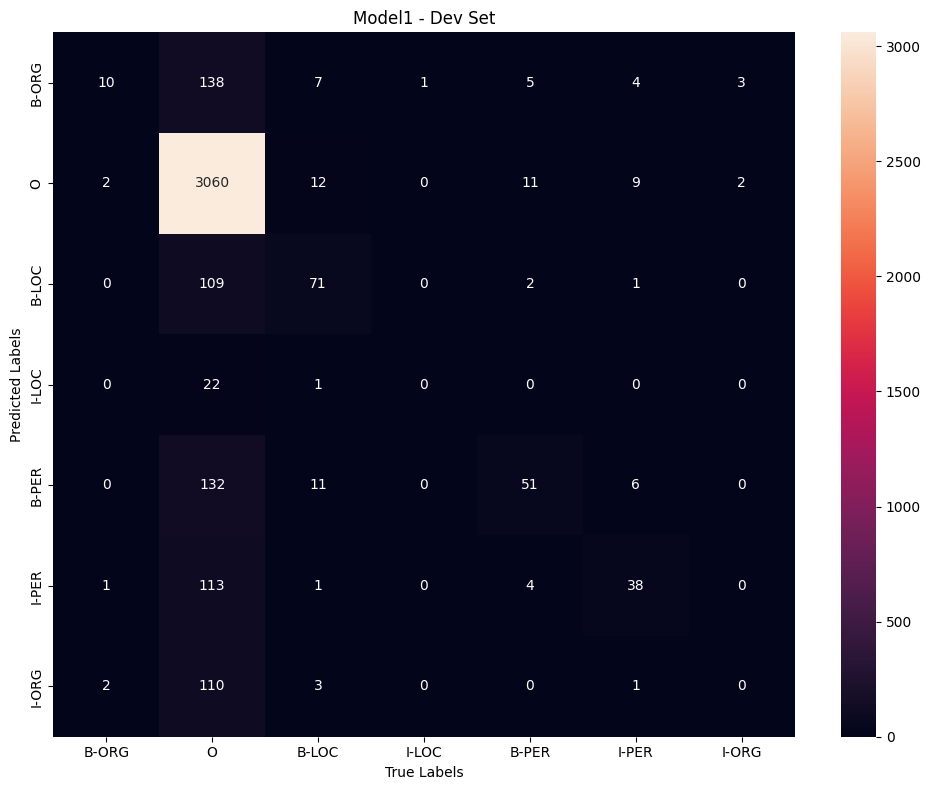


=== Training Model2 ===


Training:  20%|██        | 1/5 [00:01<00:06,  1.57s/it]

Epoch 1/5 - Train Loss: 1.1476, Train Acc: 0.7745, Dev Loss: 0.8932, Dev Acc: 0.7842


Training:  40%|████      | 2/5 [00:03<00:04,  1.57s/it]

Epoch 2/5 - Train Loss: 0.8140, Train Acc: 0.7897, Dev Loss: 0.7834, Dev Acc: 0.7847


...

Training:  80%|████████  | 4/5 [00:06<00:01,  1.57s/it]

Epoch 4/5 - Train Loss: 0.5894, Train Acc: 0.8207, Dev Loss: 0.6070, Dev Acc: 0.8123


Training: 100%|██████████| 5/5 [00:07<00:00,  1.58s/it]

Epoch 5/5 - Train Loss: 0.5069, Train Acc: 0.8351, Dev Loss: 0.6042, Dev Acc: 0.8062



--- Model2 - Dev Set ---
All labels  -> Recall: 0.8062, Precision: 0.7780, F1: 0.7780
Without O   -> Recall: 0.3140, Precision: 0.4424, F1: 0.3175


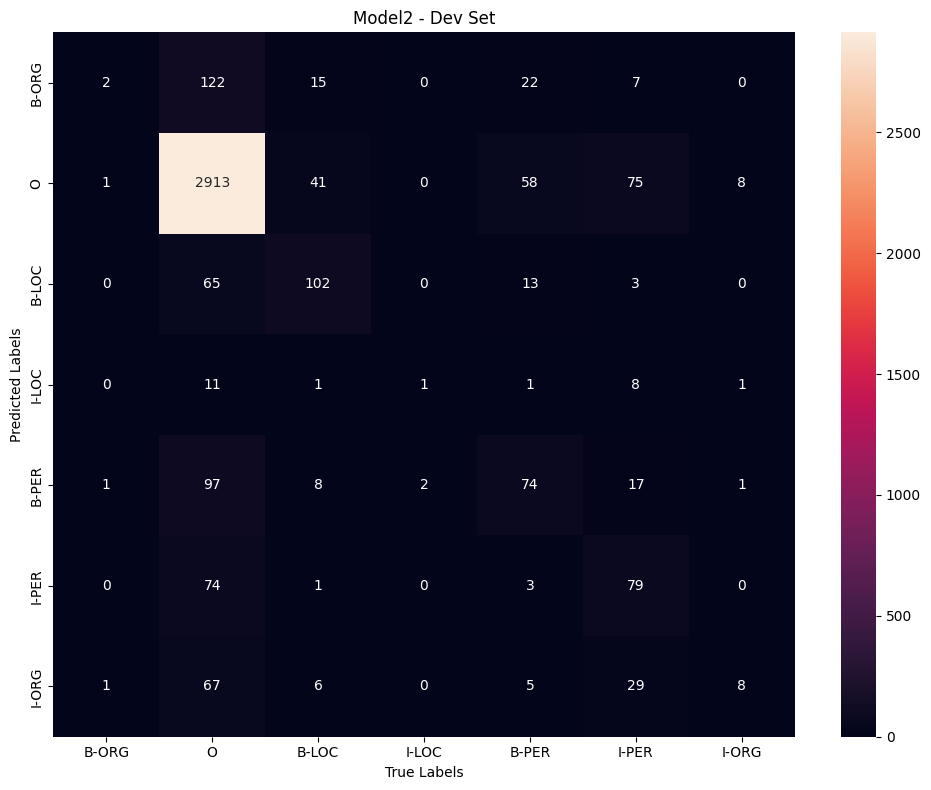


=== Training Model3 ===


Training:  20%|██        | 1/5 [00:02<00:09,  2.26s/it]

Epoch 1/5 - Train Loss: 1.1219, Train Acc: 0.7837, Dev Loss: 0.9003, Dev Acc: 0.7852


Training:  40%|████      | 2/5 [00:04<00:06,  2.26s/it]

Epoch 2/5 - Train Loss: 0.8372, Train Acc: 0.7899, Dev Loss: 0.8429, Dev Acc: 0.7849


...

Training:  80%|████████  | 4/5 [00:09<00:02,  2.27s/it]

Epoch 4/5 - Train Loss: 0.6249, Train Acc: 0.8092, Dev Loss: 0.6293, Dev Acc: 0.8111


Training: 100%|██████████| 5/5 [00:11<00:00,  2.27s/it]

Epoch 5/5 - Train Loss: 0.5101, Train Acc: 0.8352, Dev Loss: 0.5459, Dev Acc: 0.8263



--- Model3 - Dev Set ---
All labels  -> Recall: 0.8263, Precision: 0.7914, F1: 0.7921
Without O   -> Recall: 0.3483, Precision: 0.4933, F1: 0.3497


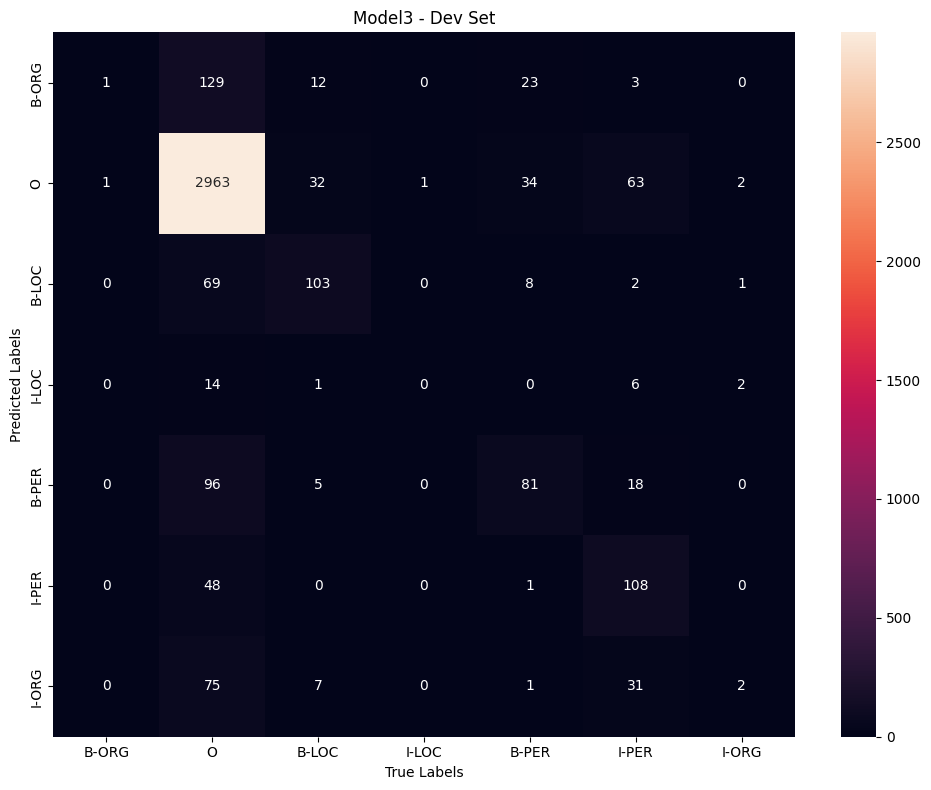


=== Training Model4 ===


Training:  20%|██        | 1/5 [00:01<00:05,  1.48s/it]

Epoch 1/5 - Train Loss: 1.0707, Train Acc: 0.7523, Dev Loss: 0.7802, Dev Acc: 0.7852


Training:  40%|████      | 2/5 [00:02<00:04,  1.47s/it]

Epoch 2/5 - Train Loss: 0.7075, Train Acc: 0.7966, Dev Loss: 0.6860, Dev Acc: 0.8009


...

Epoch 3/5 - Train Loss: 0.6101, Train Acc: 0.8188, Dev Loss: 0.6075, Dev Acc: 0.8242


Training:  80%|████████  | 4/5 [00:05<00:01,  1.47s/it]

Epoch 4/5 - Train Loss: 0.5175, Train Acc: 0.8410, Dev Loss: 0.5357, Dev Acc: 0.8405


Training: 100%|██████████| 5/5 [00:07<00:00,  1.47s/it]

Epoch 5/5 - Train Loss: 0.4402, Train Acc: 0.8632, Dev Loss: 0.4951, Dev Acc: 0.8527

--- Model4 - Dev Set ---
All labels  -> Recall: 0.8527, Precision: 0.8370, F1: 0.8270
Without O   -> Recall: 0.3719, Precision: 0.6952, F1: 0.4622


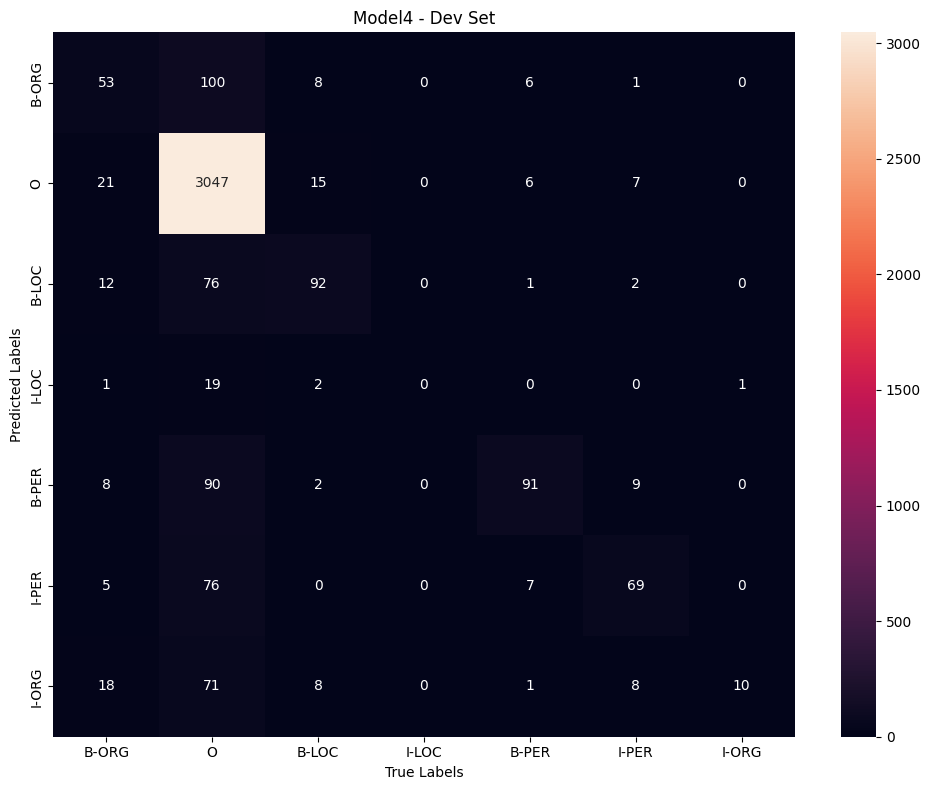


=== Training Model5 ===


Training:  20%|██        | 1/5 [00:03<00:13,  3.34s/it]

Epoch 1/5 - Train Loss: 0.9867, Train Acc: 0.7802, Dev Loss: 0.7819, Dev Acc: 0.7852


Training:  40%|████      | 2/5 [00:06<00:10,  3.45s/it]

Epoch 2/5 - Train Loss: 0.6972, Train Acc: 0.8002, Dev Loss: 0.6359, Dev Acc: 0.8242


...

Training:  80%|████████  | 4/5 [00:13<00:03,  3.49s/it]

Epoch 4/5 - Train Loss: 0.3850, Train Acc: 0.8790, Dev Loss: 0.4349, Dev Acc: 0.8636


Training: 100%|██████████| 5/5 [00:17<00:00,  3.47s/it]

Epoch 5/5 - Train Loss: 0.2769, Train Acc: 0.9100, Dev Loss: 0.4074, Dev Acc: 0.8689



--- Model5 - Dev Set ---
All labels  -> Recall: 0.8689, Precision: 0.8752, F1: 0.8703
Without O   -> Recall: 0.6446, Precision: 0.6147, F1: 0.6219


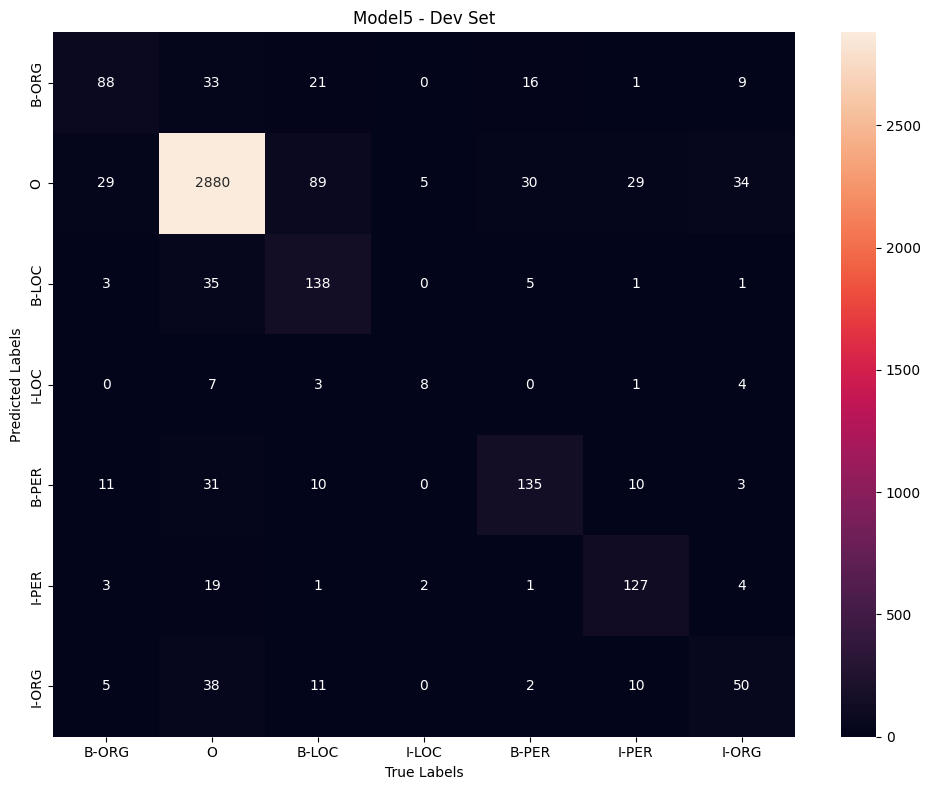


=== Training Model6 ===


Training:  20%|██        | 1/5 [00:05<00:21,  5.25s/it]

Epoch 1/5 - Train Loss: 0.9663, Train Acc: 0.7698, Dev Loss: 0.8292, Dev Acc: 0.7852


Training:  40%|████      | 2/5 [00:10<00:15,  5.29s/it]

Epoch 2/5 - Train Loss: 0.7325, Train Acc: 0.7926, Dev Loss: 0.7321, Dev Acc: 0.7948


...

Training:  80%|████████  | 4/5 [00:21<00:05,  5.34s/it]

Epoch 4/5 - Train Loss: 0.3793, Train Acc: 0.8770, Dev Loss: 0.6439, Dev Acc: 0.8527


Training: 100%|██████████| 5/5 [00:26<00:00,  5.35s/it]

Epoch 5/5 - Train Loss: 0.2401, Train Acc: 0.9257, Dev Loss: 0.5558, Dev Acc: 0.8722



--- Model6 - Dev Set ---
All labels  -> Recall: 0.8722, Precision: 0.8634, F1: 0.8563
Without O   -> Recall: 0.4616, Precision: 0.7758, F1: 0.5747


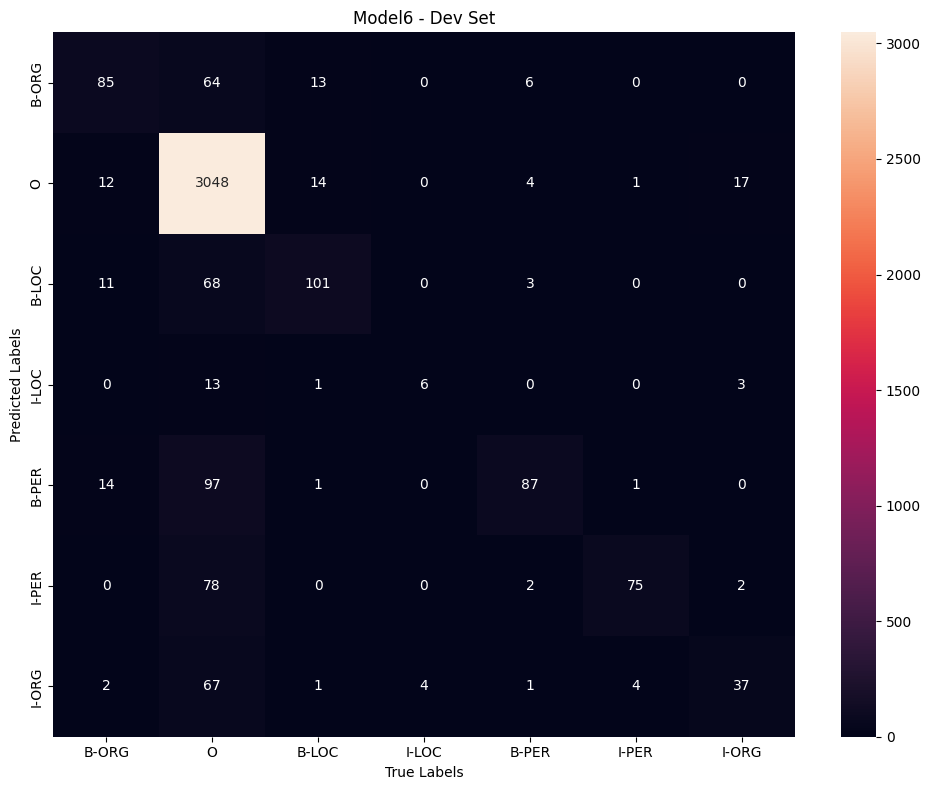


=== Training Model7 ===


Training:  20%|██        | 1/5 [00:03<00:13,  3.48s/it]

Epoch 1/5 - Train Loss: 0.9973, Train Acc: 0.7656, Dev Loss: 0.7517, Dev Acc: 0.7877


Training:  40%|████      | 2/5 [00:06<00:10,  3.50s/it]

Epoch 2/5 - Train Loss: 0.6592, Train Acc: 0.8109, Dev Loss: 0.6265, Dev Acc: 0.8273


...

Training:  80%|████████  | 4/5 [00:14<00:03,  3.53s/it]

Epoch 4/5 - Train Loss: 0.4388, Train Acc: 0.8641, Dev Loss: 0.4885, Dev Acc: 0.8534


Training: 100%|██████████| 5/5 [00:17<00:00,  3.53s/it]

Epoch 5/5 - Train Loss: 0.3620, Train Acc: 0.8853, Dev Loss: 0.4631, Dev Acc: 0.8595



--- Model7 - Dev Set ---
All labels  -> Recall: 0.8595, Precision: 0.8463, F1: 0.8367
Without O   -> Recall: 0.4274, Precision: 0.6999, F1: 0.4963


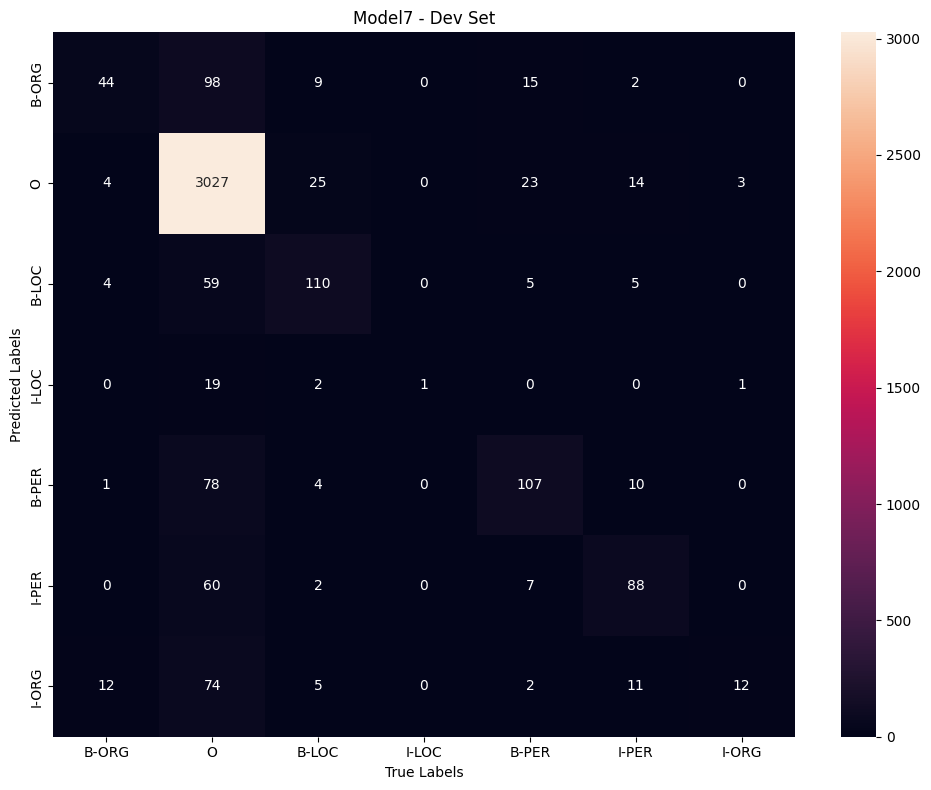


=== Training Model8 ===


Training:  20%|██        | 1/5 [00:09<00:36,  9.13s/it]

Epoch 1/5 - Train Loss: 0.9058, Train Acc: 0.7856, Dev Loss: 0.7335, Dev Acc: 0.7900


Training:  40%|████      | 2/5 [00:18<00:27,  9.25s/it]

Epoch 2/5 - Train Loss: 0.6054, Train Acc: 0.8250, Dev Loss: 0.5616, Dev Acc: 0.8367


...

Training:  80%|████████  | 4/5 [00:37<00:09,  9.34s/it]

Epoch 4/5 - Train Loss: 0.3031, Train Acc: 0.9018, Dev Loss: 0.4115, Dev Acc: 0.8689


Training: 100%|██████████| 5/5 [00:46<00:00,  9.34s/it]

Epoch 5/5 - Train Loss: 0.2018, Train Acc: 0.9367, Dev Loss: 0.3752, Dev Acc: 0.8816



--- Model8 - Dev Set ---
All labels  -> Recall: 0.8816, Precision: 0.8791, F1: 0.8788
Without O   -> Recall: 0.6375, Precision: 0.6757, F1: 0.6496


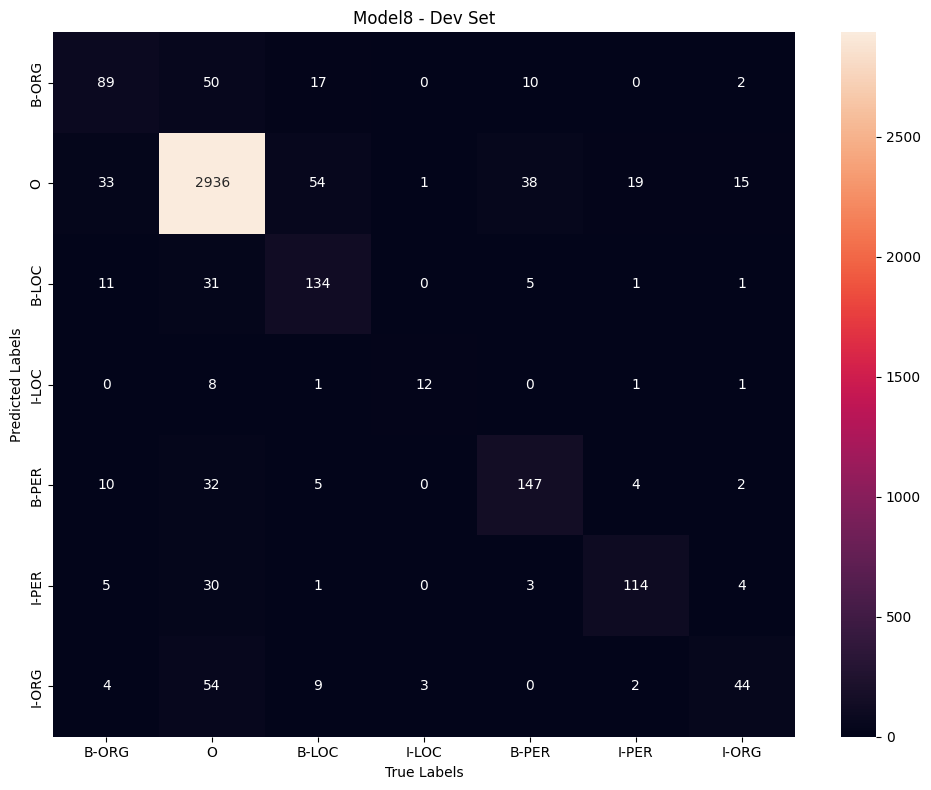


=== Training Model9 ===


Training:  20%|██        | 1/5 [00:15<01:02, 15.56s/it]

Epoch 1/5 - Train Loss: 0.9156, Train Acc: 0.7838, Dev Loss: 0.7879, Dev Acc: 0.7852


Training:  40%|████      | 2/5 [00:31<00:46, 15.61s/it]

Epoch 2/5 - Train Loss: 0.6848, Train Acc: 0.8038, Dev Loss: 0.6307, Dev Acc: 0.8250


...

Training:  80%|████████  | 4/5 [01:03<00:15, 15.87s/it]

Epoch 4/5 - Train Loss: 0.2976, Train Acc: 0.9052, Dev Loss: 0.4241, Dev Acc: 0.8778


Training: 100%|██████████| 5/5 [01:19<00:00, 15.90s/it]

Epoch 5/5 - Train Loss: 0.1771, Train Acc: 0.9444, Dev Loss: 0.4917, Dev Acc: 0.8950



--- Model9 - Dev Set ---
All labels  -> Recall: 0.8950, Precision: 0.8902, F1: 0.8818
Without O   -> Recall: 0.5360, Precision: 0.8372, F1: 0.6438


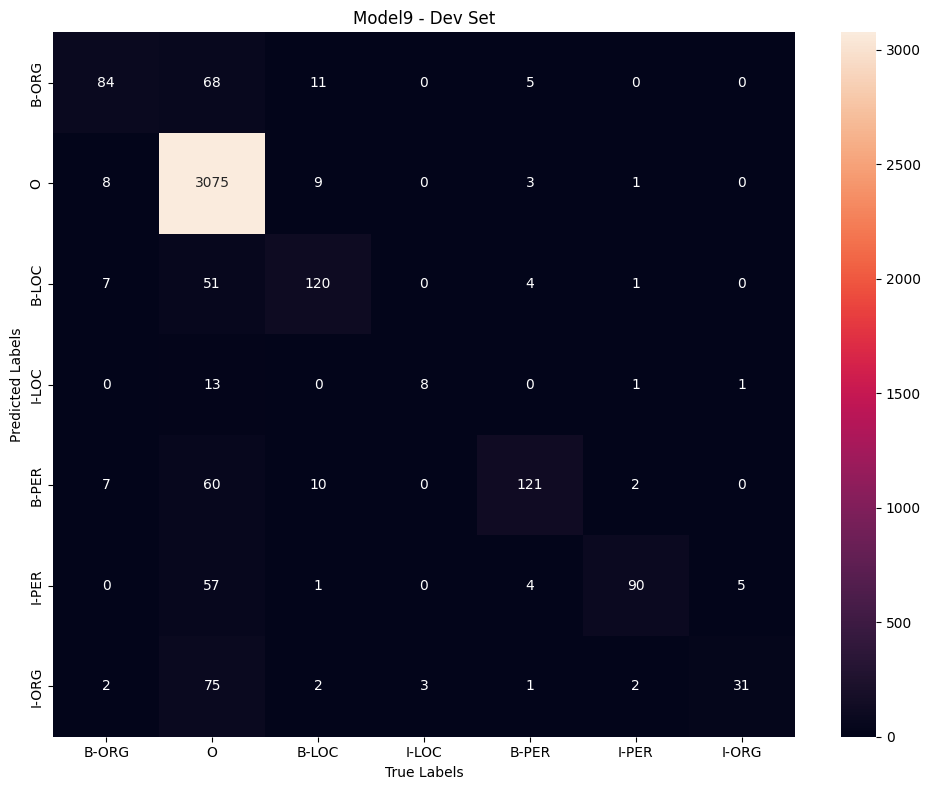

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | Model1    |           500 |          1 |            1 |   0.8192 |      0.7728 | 0.7692 |        0.2007 |           0.5613 |    0.2813 |
|  1 | Model2    |           500 |          2 |            1 |   0.8062 |      0.7780 | 0.7780 |        0.3140 |           0.4424 |    0.3175 |
|  2 | Model3    |           500 |          3 |            1 |   0.8263 |      0.7914 | 0.7921 |        0.3483 |           0.4933 |    0.3497 |
|  3 | Model4    |           500 |          1 |            2 |   0.8527 |      0.8370 | 0.8270 |        0.3719 |           0.6952 |    0

In [23]:
# Define models with their hyperparameters
models = {
  'Model1': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 1},
  'Model2': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 1},
  'Model3': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 1},
  'Model4': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 2},
  'Model5': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 2},
  'Model6': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 2},
  'Model7': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 1, 'directions': 2},
  'Model8': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2},
  'Model9': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 3, 'directions': 2},
}

# TO DO ----------------------------------------------------------------------
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PRECISION','F1','RECALL_WO_O','PRECISION_WO_O','F1_WO_O']
rows = []

trained_models = {}
for name, cfg in models.items():
    print(f'\n=== Training {name} ===')
    m = NERNet(vocab.n_words, embedding_size=cfg['embedding_size'], hidden_size=cfg['hidden_size'],
              output_size=vocab.n_tags, n_layers=cfg['n_layers'], directions=cfg['directions'])
    m.to(DEVICE)
    _ = train_loop(m, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
    res = evaluate(m, title=f'{name} - Dev Set', dataloader=dl_dev, vocab=vocab)
    trained_models[name] = m
    rows.append([name, cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
                 res['RECALL'], res['PRECISION'], res['F1'],
                 res['RECALL_WO_O'], res['PRECISION_WO_O'], res['F1_WO_O']])

results_dev = pd.DataFrame(rows, columns=columns)
# TO DO ----------------------------------------------------------------------

# Print results in tabulated format
print(tabulate(results_dev, headers='keys', tablefmt='psql', floatfmt=".4f"))

## Step 3: Evaluate on Test Set
Evaluate your models on the test set and save the results as a CSV.


--- Model1 - Test Set ---
All labels  -> Recall: 0.8272, Precision: 0.7909, F1: 0.7789
Without O   -> Recall: 0.1939, Precision: 0.6000, F1: 0.2723


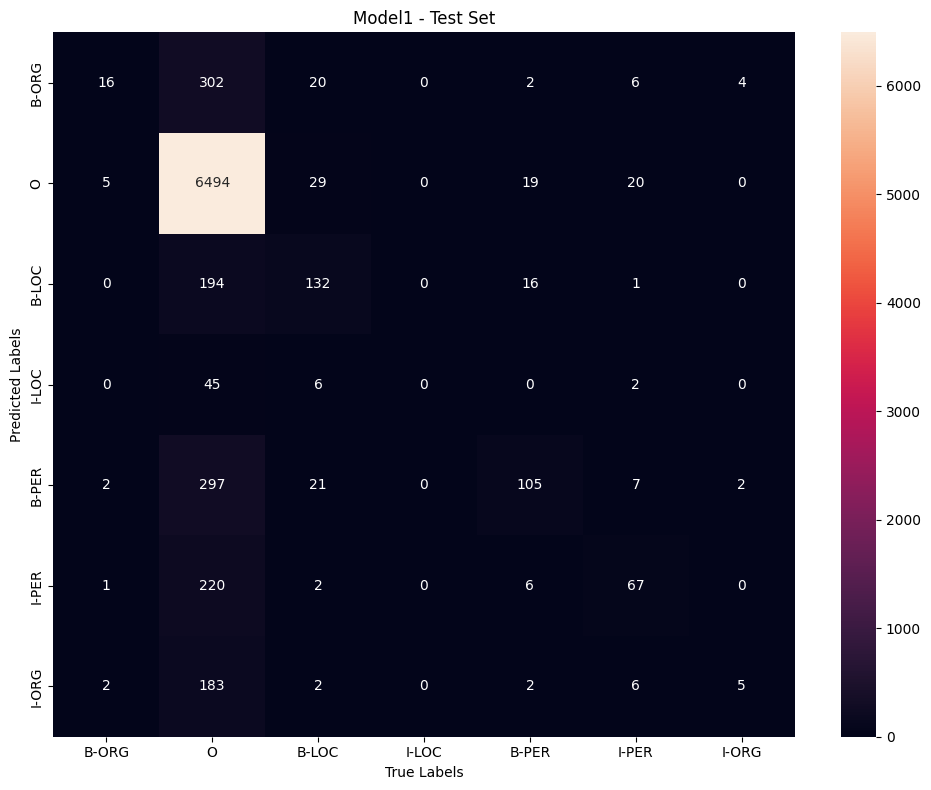


--- Model2 - Test Set ---
All labels  -> Recall: 0.8084, Precision: 0.7744, F1: 0.7793
Without O   -> Recall: 0.2930, Precision: 0.4083, F1: 0.2968


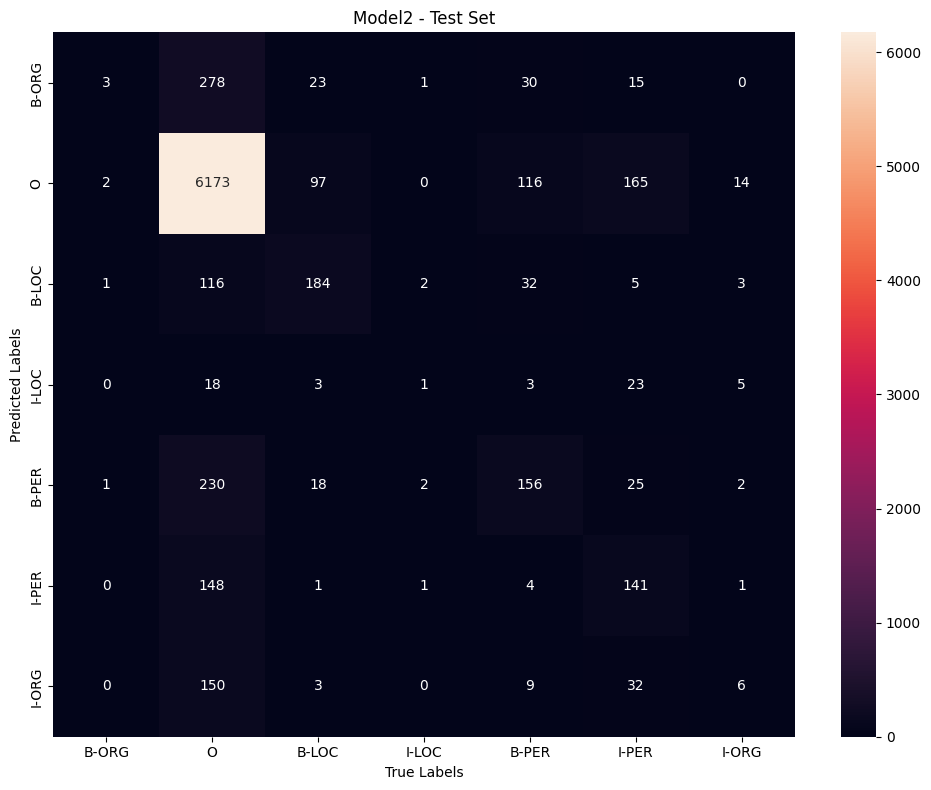


--- Model3 - Test Set ---
All labels  -> Recall: 0.8272, Precision: 0.7710, F1: 0.7949
Without O   -> Recall: 0.3240, Precision: 0.3622, F1: 0.3292


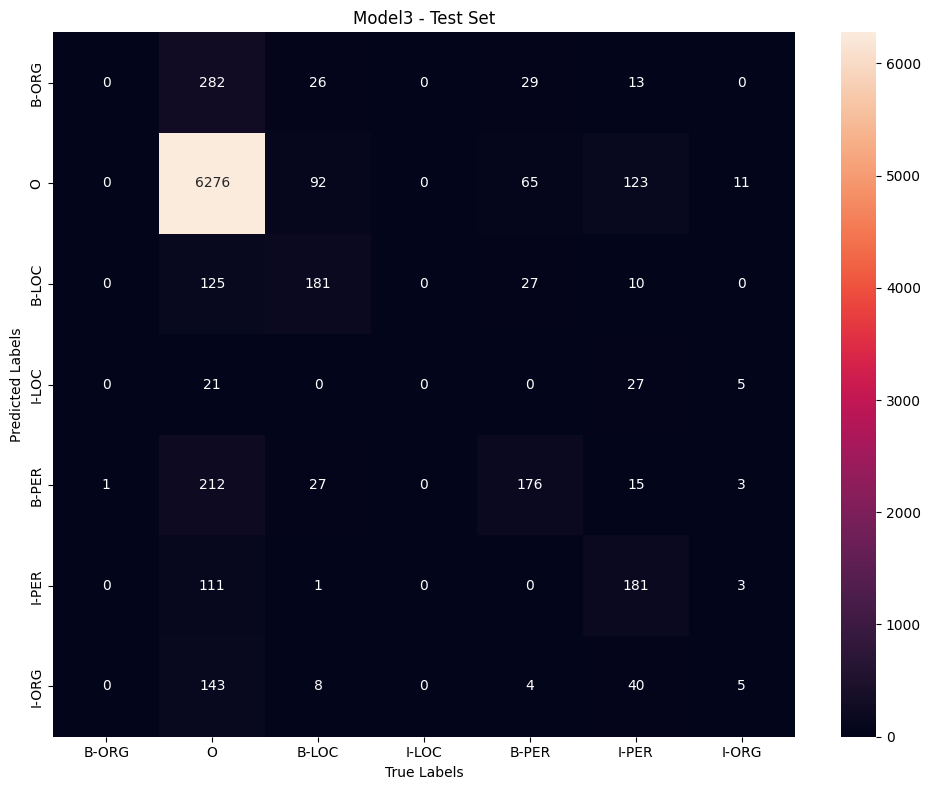


--- Model4 - Test Set ---
All labels  -> Recall: 0.8596, Precision: 0.8412, F1: 0.8372
Without O   -> Recall: 0.3920, Precision: 0.6744, F1: 0.4778


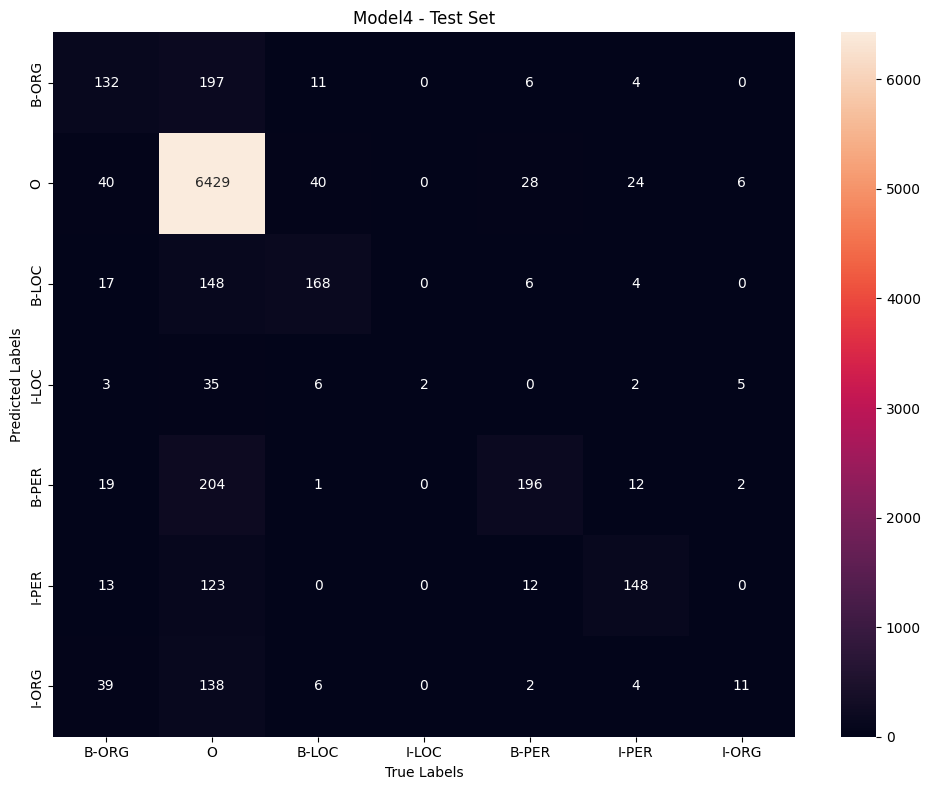


--- Model5 - Test Set ---
All labels  -> Recall: 0.8664, Precision: 0.8754, F1: 0.8691
Without O   -> Recall: 0.6360, Precision: 0.5977, F1: 0.6086


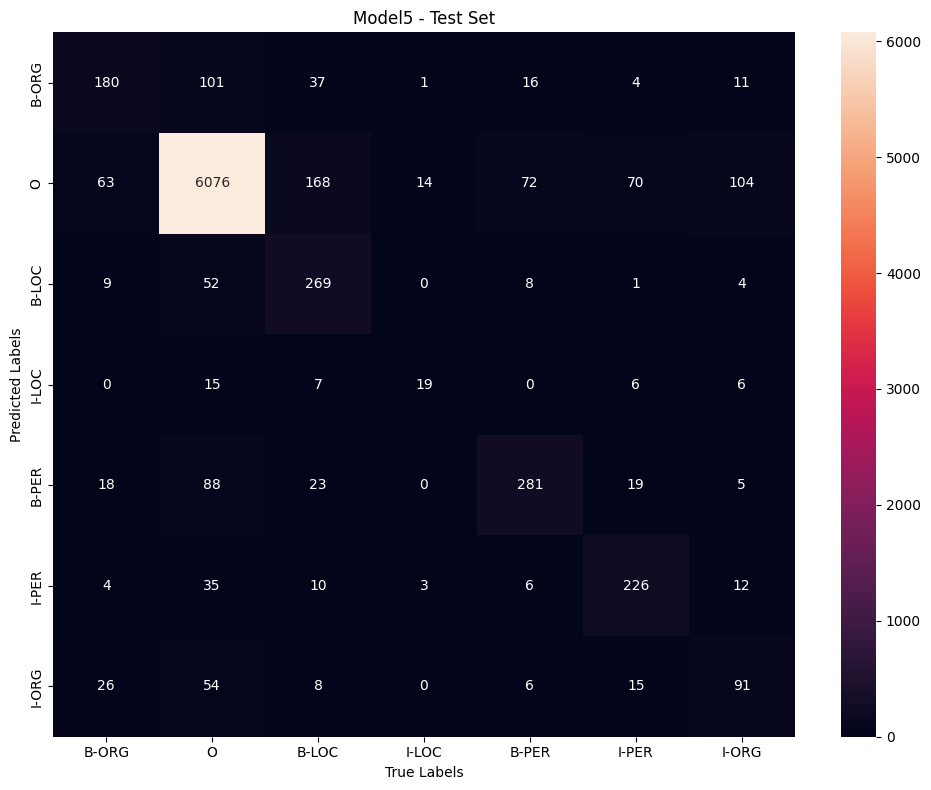


--- Model6 - Test Set ---
All labels  -> Recall: 0.8829, Precision: 0.8783, F1: 0.8661
Without O   -> Recall: 0.4594, Precision: 0.8370, F1: 0.5877


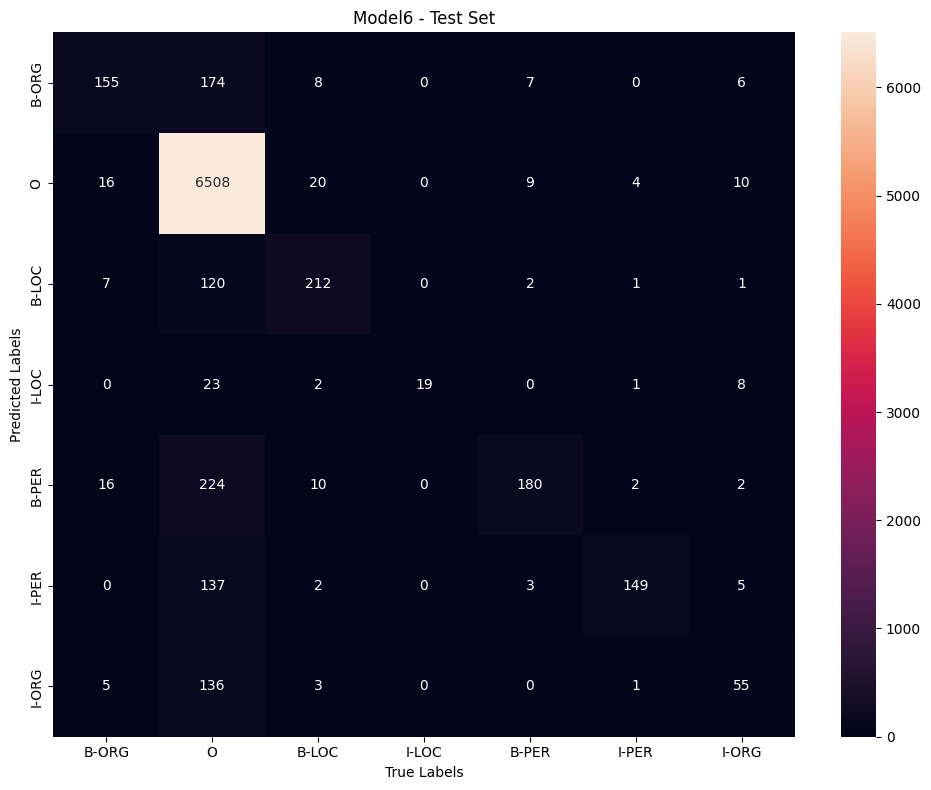


--- Model7 - Test Set ---
All labels  -> Recall: 0.8649, Precision: 0.8569, F1: 0.8436
Without O   -> Recall: 0.4338, Precision: 0.7275, F1: 0.5035


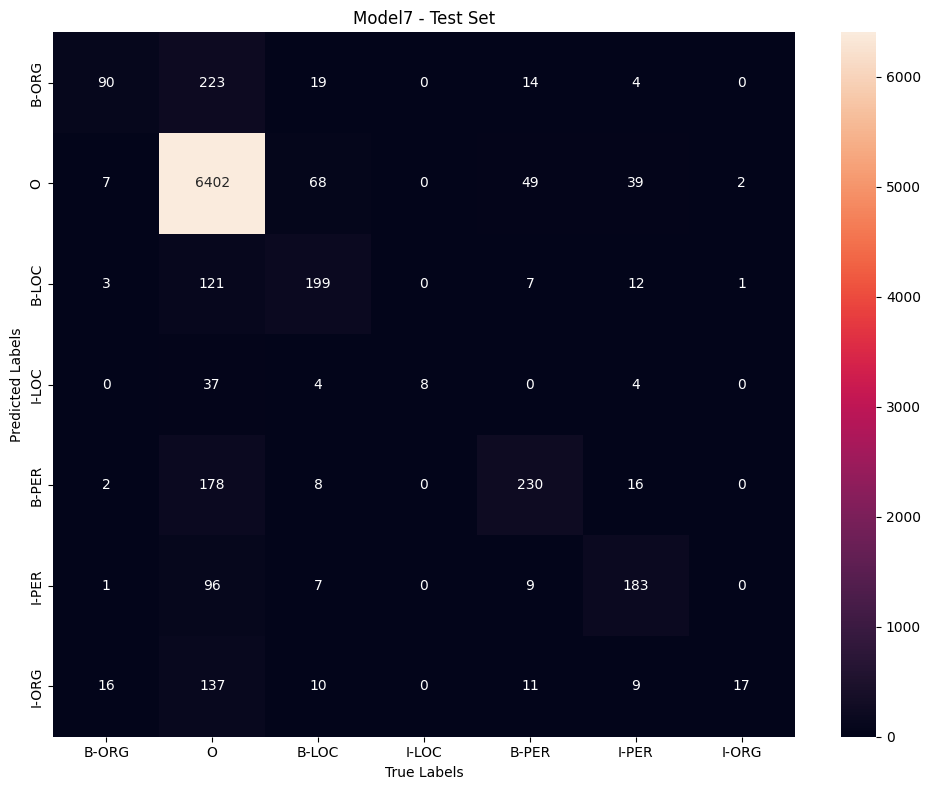


--- Model8 - Test Set ---
All labels  -> Recall: 0.8855, Precision: 0.8844, F1: 0.8839
Without O   -> Recall: 0.6635, Precision: 0.6571, F1: 0.6551


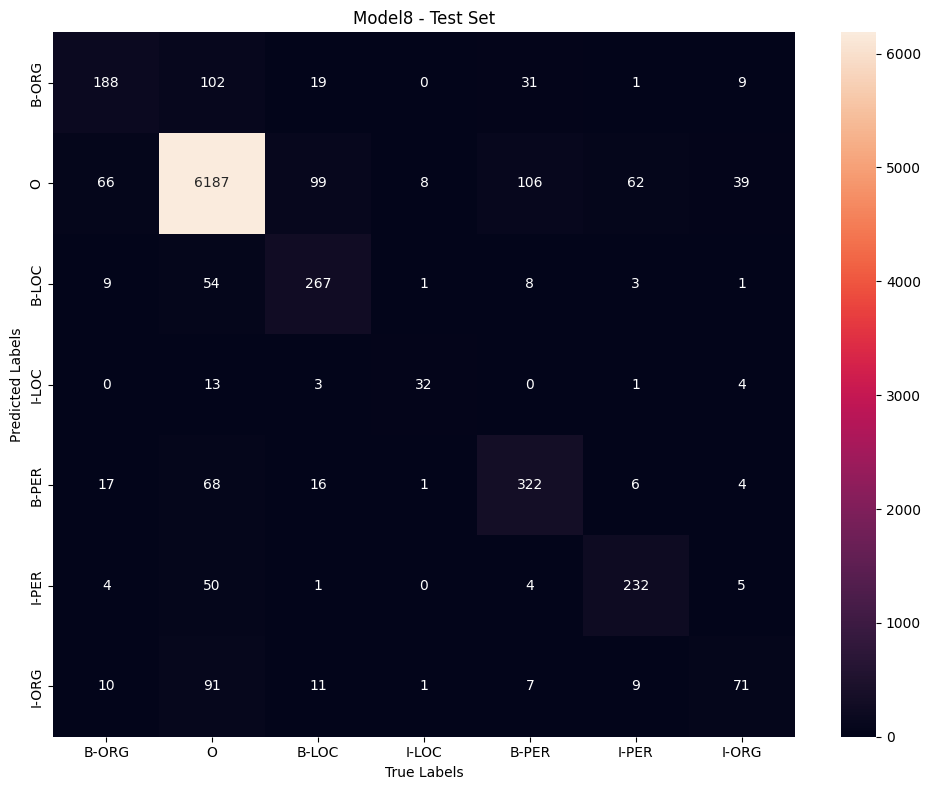


--- Model9 - Test Set ---
All labels  -> Recall: 0.8992, Precision: 0.8930, F1: 0.8881
Without O   -> Recall: 0.5483, Precision: 0.8284, F1: 0.6553


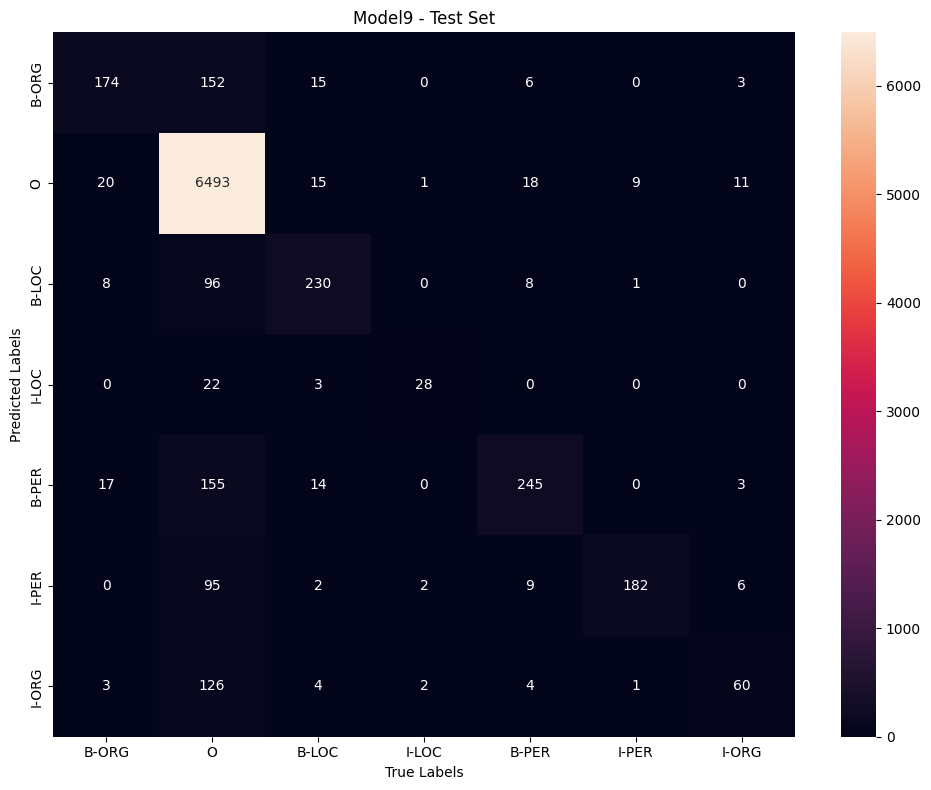

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | Model1    |           500 |          1 |            1 |   0.8272 |      0.7909 | 0.7789 |        0.1939 |           0.6000 |    0.2723 |
|  1 | Model2    |           500 |          2 |            1 |   0.8084 |      0.7744 | 0.7793 |        0.2930 |           0.4083 |    0.2968 |
|  2 | Model3    |           500 |          3 |            1 |   0.8272 |      0.7710 | 0.7949 |        0.3240 |           0.3622 |    0.3292 |
|  3 | Model4    |           500 |          1 |            2 |   0.8596 |      0.8412 | 0.8372 |        0.3920 |           0.6744 |    0

In [24]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results.csv"
# TO DO ----------------------------------------------------------------------
rows = []
for name, cfg in models.items():
    m = trained_models[name]
    res = evaluate(m, title=f'{name} - Test Set', dataloader=dl_test, vocab=vocab)
    rows.append([name, cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
                 res['RECALL'], res['PRECISION'], res['F1'],
                 res['RECALL_WO_O'], res['PRECISION_WO_O'], res['F1_WO_O']])

results = pd.DataFrame(rows, columns=columns)
results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))


## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Training:  10%|█         | 1/10 [00:16<02:25, 16.13s/it]

Epoch 1/10 - Train Loss: 0.9197, Train Acc: 0.7871, Dev Loss: 0.7919, Dev Acc: 0.7852


Training:  20%|██        | 2/10 [00:32<02:10, 16.29s/it]

Epoch 2/10 - Train Loss: 0.7034, Train Acc: 0.7995, Dev Loss: 0.6500, Dev Acc: 0.8227


Training:  30%|███       | 3/10 [00:48<01:54, 16.35s/it]

...

Training:  90%|█████████ | 9/10 [02:30<00:16, 16.94s/it]

Epoch 9/10 - Train Loss: 0.0173, Train Acc: 0.9957, Dev Loss: 0.4575, Dev Acc: 0.8945


Training: 100%|██████████| 10/10 [02:47<00:00, 16.73s/it]

Epoch 10/10 - Train Loss: 0.0110, Train Acc: 0.9976, Dev Loss: 0.4587, Dev Acc: 0.9062



--- Best Baseline - Test Set (10 epochs) ---
All labels  -> Recall: 0.9113, Precision: 0.9116, F1: 0.9091
Without O   -> Recall: 0.6963, Precision: 0.7433, F1: 0.7083


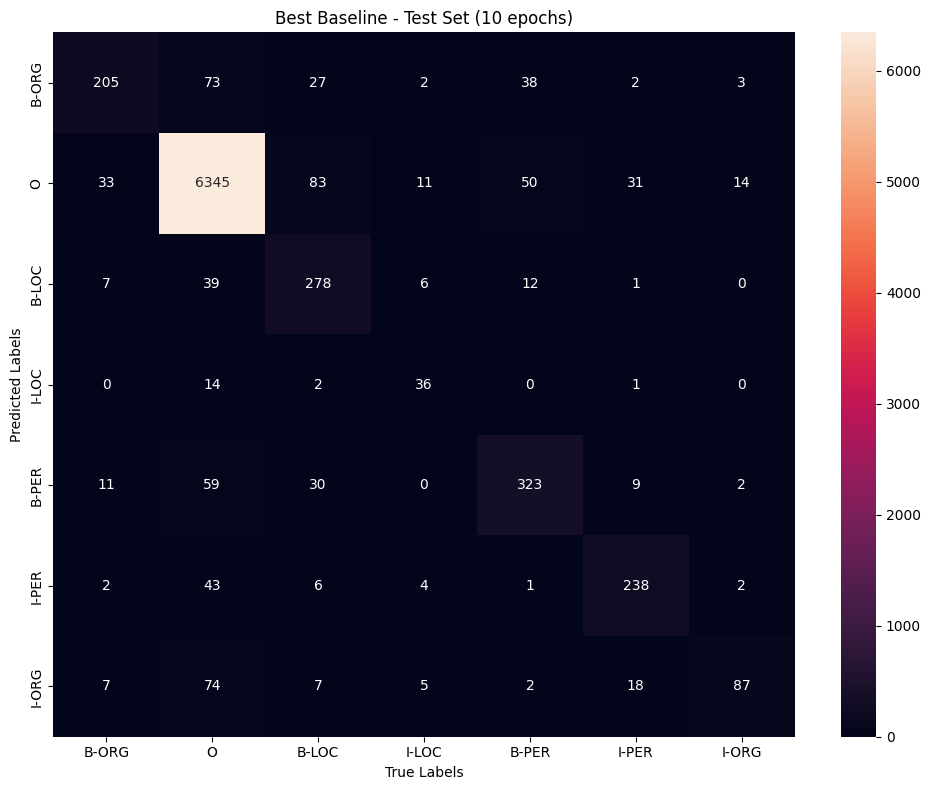

{'RECALL': 0.911318694650006, 'PRECISION': 0.9116125846122647, 'F1': 0.9090970514472091, 'RECALL_WO_O': 0.6963007159904535, 'PRECISION_WO_O': 0.7433101506728665, 'F1_WO_O': 0.7082940325901211}


<Figure size 640x480 with 0 Axes>

In [25]:
best_model_cfg = {'embedding_size':EMB_DIM, 'hidden_size': 800, 'n_layers': 3, 'directions': 2}
# TO DO ----------------------------------------------------------------------
# Best model is Model9: hidden_size=800, n_layers=3, directions=2
best_baseline = NERNet(vocab.n_words, embedding_size=EMB_DIM, hidden_size=800,
                       output_size=vocab.n_tags, n_layers=3, directions=2)
best_baseline.to(DEVICE)
_ = train_loop(best_baseline, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
best_baseline_results = evaluate(best_baseline, title='Best Baseline - Test Set (10 epochs)', dataloader=dl_test, vocab=vocab)
print(best_baseline_results)

# Save confusion matrix
plt.savefig('Best_Baseline_Test_Confusion_Matrix.png')
# TO DO ----------------------------------------------------------------------

<br><br><br><br><br>

# Part 4 - Pretrained Embeddings



To prepare for this task, please read [this discussion](https://discuss.pytorch.org/t/can-we-use-pre-trained-word-embeddings-for-weight-initialization-in-nn-embedding/1222).

**TIP**: Ensure that the vectors are aligned with the IDs in your vocabulary. In other words, make sure that the word with ID 0 corresponds to the first vector in the GloVe matrix used to initialize `nn.Embedding`.



## Step 1: Get Data



Download the GloVe embeddings from [this link](https://nlp.stanford.edu/projects/glove/). Use the 300-dimensional vectors from `glove.6B.zip`.



In [26]:
# Download GloVe embeddings (300d) with a timeout and continuation support
!wget -c -O glove.6B.zip https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip -o glove.6B.zip glove.6B.300d.txt
!ls -lh glove.6B.300d.txt
!rm glove.6B.zip

--2026-06-14 17:58:38--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.03MB/s    in 2m 40s  

2026-06-14 18:01:18 (5.15 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

Archive:  glove.6B.zip
  inflating: glove.6B.300d.txt       
-rw-rw-r-- 1 root root 990M Aug 27  2014 glove.6B.300d.txt


## Step 2: Inject Embeddings

Then intialize the `nn.Embedding` module in your `NERNet` with these embeddings, so that you can start your training with pre-trained vectors.

In [27]:
def get_emb_matrix(filepath: str, vocab: Vocab) -> np.ndarray:
  emb_matrix = np.zeros((len(vocab.word2id), 300))
  # TO DO ----------------------------------------------------------------------
  emb_matrix[vocab.word2id["__unk__"]] = np.random.normal(scale=0.6, size=(300,))
  with open(filepath, 'r', encoding='utf-8') as f:
      for line in f:
          parts = line.strip().split()
          if len(parts) == 301:
              word = parts[0]
              if word in vocab.word2id:
                  idx = vocab.word2id[word]
                  emb_matrix[idx] = np.array(parts[1:], dtype=np.float32)
  # TO DO ----------------------------------------------------------------------
  return emb_matrix

In [28]:
def get_emb_matrix_improved(filepath: str, vocab: Vocab) -> np.ndarray:
    """
    Improved embedding matrix builder: uses lowercasing for better GloVe matching
    """
    emb_matrix = np.zeros((len(vocab.word2id), 300))
    # Use a smaller scale for random initialization of UNK
    emb_matrix[vocab.word2id["__unk__"]] = np.random.normal(scale=0.1, size=(300,))

    glove_dict = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 301:
                glove_dict[parts[0]] = np.array(parts[1:], dtype=np.float32)

    count = 0
    for word, idx in vocab.word2id.items():
        # Try original word, then lowercase version
        if word in glove_dict:
            emb_matrix[idx] = glove_dict[word]
            count += 1
        elif word.lower() in glove_dict:
            emb_matrix[idx] = glove_dict[word.lower()]
            count += 1

    print(f"✅ Successfully matched {count} / {len(vocab.word2id)} words with GloVe")
    return emb_matrix

In [29]:
def initialize_from_pretrained_emb(model: NERNet, emb_matrix: np.ndarray):
  """
  Inject the pretrained embeddings into the model.
  :param model: model instance
  :param emb_matrix: pretrained embeddings
  """
  # TO DO ----------------------------------------------------------------------
  model.embedding.weight.data.copy_(th.from_numpy(emb_matrix))
  # TO DO ----------------------------------------------------------------------

In [30]:
# Read embeddings and inject them to a model
emb_file = 'glove.6B.300d.txt'
emb_matrix = get_emb_matrix(emb_file, vocab)
ner_glove = NERNet(input_size=vocab.n_words, embedding_size=EMB_DIM, hidden_size=500, output_size=vocab.n_tags, n_layers=1, directions=1)
initialize_from_pretrained_emb(ner_glove, emb_matrix)

## Step 3: Evaluate on Test Set

Same as the evaluation process before, please display:

1. Print a `RECALL-PRECISION-F1` scores in a tabulate format.
2. Display a `confusion matrix` plot: where the predicted labels are the rows, and the true labels are the columns.

Make sure to use the title for the plot, axis names, and the names of the tags on the X-axis.

The CSV will be submitted automatically along with your results.


=== Training Model1 with GloVe ===


Training:  20%|██        | 1/5 [00:01<00:04,  1.09s/it]

Epoch 1/5 - Train Loss: 1.1120, Train Acc: 0.7514, Dev Loss: 0.8141, Dev Acc: 0.7827


Training:  40%|████      | 2/5 [00:02<00:03,  1.02s/it]

Epoch 2/5 - Train Loss: 0.7228, Train Acc: 0.7865, Dev Loss: 0.6806, Dev Acc: 0.7829


...

Training:  80%|████████  | 4/5 [00:04<00:00,  1.01it/s]

Epoch 4/5 - Train Loss: 0.5079, Train Acc: 0.8272, Dev Loss: 0.5148, Dev Acc: 0.8303


Training: 100%|██████████| 5/5 [00:04<00:00,  1.01it/s]

Epoch 5/5 - Train Loss: 0.4520, Train Acc: 0.8480, Dev Loss: 0.4891, Dev Acc: 0.8362



--- Model1 GloVe - Test Set ---
All labels  -> Recall: 0.8450, Precision: 0.8153, F1: 0.8074
Without O   -> Recall: 0.2768, Precision: 0.6230, F1: 0.3547


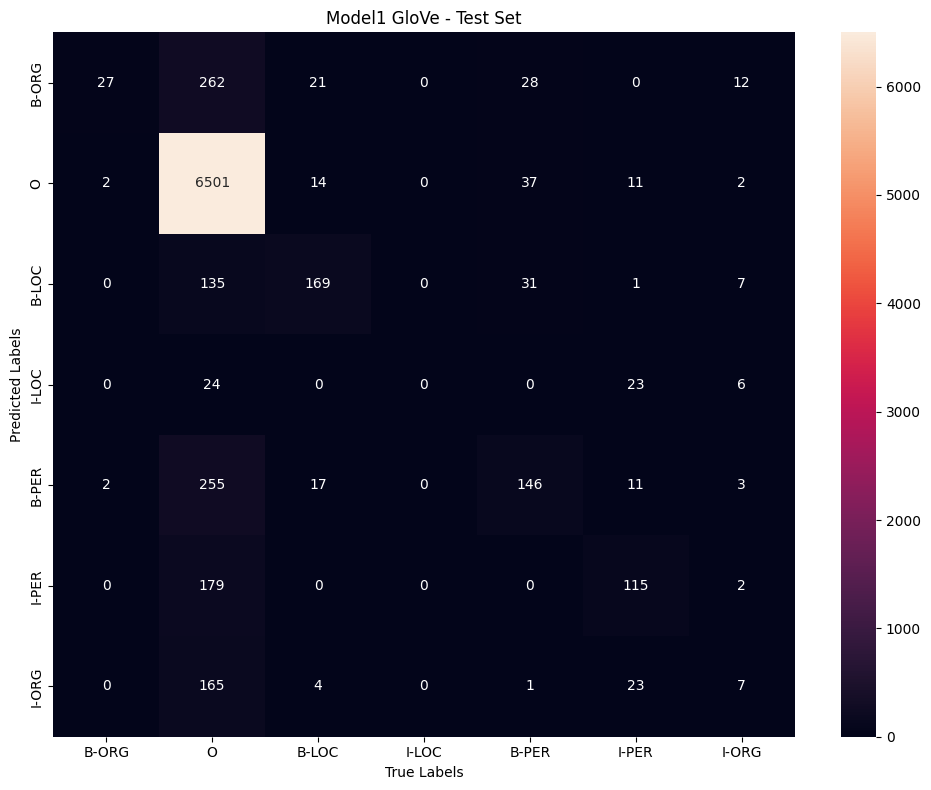


=== Training Model2 with GloVe ===


Training:  20%|██        | 1/5 [00:01<00:07,  1.77s/it]

Epoch 1/5 - Train Loss: 1.0786, Train Acc: 0.7642, Dev Loss: 0.8142, Dev Acc: 0.7819


Training:  40%|████      | 2/5 [00:03<00:05,  1.78s/it]

Epoch 2/5 - Train Loss: 0.6680, Train Acc: 0.7881, Dev Loss: 0.6066, Dev Acc: 0.7928


...

Training:  80%|████████  | 4/5 [00:07<00:01,  1.80s/it]

Epoch 4/5 - Train Loss: 0.4568, Train Acc: 0.8344, Dev Loss: 0.5630, Dev Acc: 0.8258


Training: 100%|██████████| 5/5 [00:08<00:00,  1.80s/it]

Epoch 5/5 - Train Loss: 0.4075, Train Acc: 0.8511, Dev Loss: 0.5909, Dev Acc: 0.8319



--- Model2 GloVe - Test Set ---
All labels  -> Recall: 0.8425, Precision: 0.7999, F1: 0.8001
Without O   -> Recall: 0.2452, Precision: 0.5583, F1: 0.3169


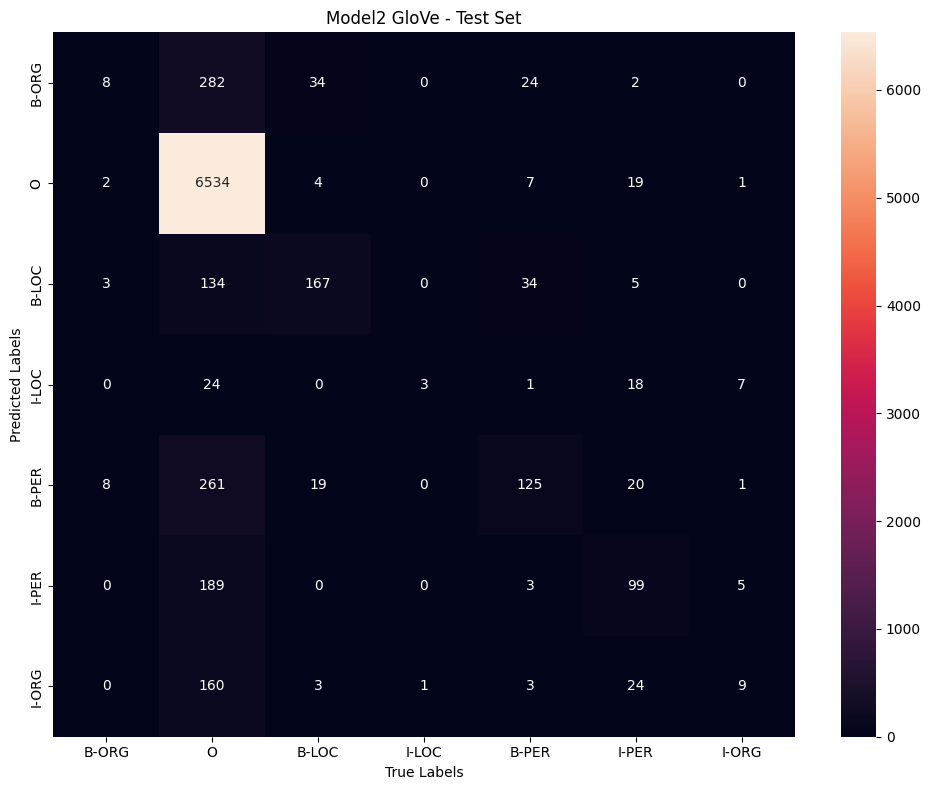


=== Training Model3 with GloVe ===


Training:  20%|██        | 1/5 [00:02<00:10,  2.55s/it]

Epoch 1/5 - Train Loss: 1.0928, Train Acc: 0.7582, Dev Loss: 0.8679, Dev Acc: 0.7839


Training:  40%|████      | 2/5 [00:05<00:07,  2.56s/it]

Epoch 2/5 - Train Loss: 0.7074, Train Acc: 0.7876, Dev Loss: 0.5825, Dev Acc: 0.8024


...

Training:  80%|████████  | 4/5 [00:10<00:02,  2.58s/it]

Epoch 4/5 - Train Loss: 0.4498, Train Acc: 0.8360, Dev Loss: 0.4781, Dev Acc: 0.8326


Training: 100%|██████████| 5/5 [00:12<00:00,  2.57s/it]

Epoch 5/5 - Train Loss: 0.3951, Train Acc: 0.8536, Dev Loss: 0.4797, Dev Acc: 0.8354



--- Model3 GloVe - Test Set ---
All labels  -> Recall: 0.8428, Precision: 0.7944, F1: 0.8098
Without O   -> Recall: 0.2816, Precision: 0.4409, F1: 0.3287


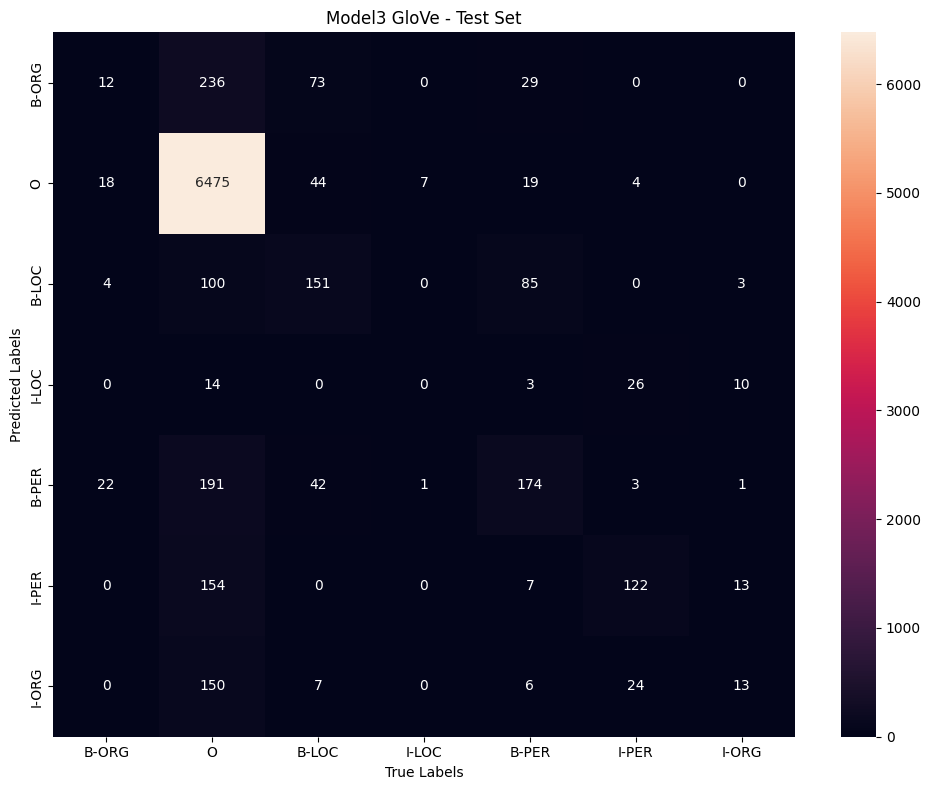


=== Training Model4 with GloVe ===


Training:  20%|██        | 1/5 [00:01<00:06,  1.63s/it]

Epoch 1/5 - Train Loss: 0.9757, Train Acc: 0.7711, Dev Loss: 0.7306, Dev Acc: 0.7842


Training:  40%|████      | 2/5 [00:03<00:04,  1.64s/it]

Epoch 2/5 - Train Loss: 0.6401, Train Acc: 0.7977, Dev Loss: 0.5922, Dev Acc: 0.8050


...

Training:  80%|████████  | 4/5 [00:06<00:01,  1.66s/it]

Epoch 4/5 - Train Loss: 0.3943, Train Acc: 0.8687, Dev Loss: 0.4168, Dev Acc: 0.8691


Training: 100%|██████████| 5/5 [00:08<00:00,  1.66s/it]

Epoch 5/5 - Train Loss: 0.3352, Train Acc: 0.8899, Dev Loss: 0.4000, Dev Acc: 0.8653



--- Model4 GloVe - Test Set ---
All labels  -> Recall: 0.8752, Precision: 0.8524, F1: 0.8513
Without O   -> Recall: 0.4147, Precision: 0.6840, F1: 0.4980


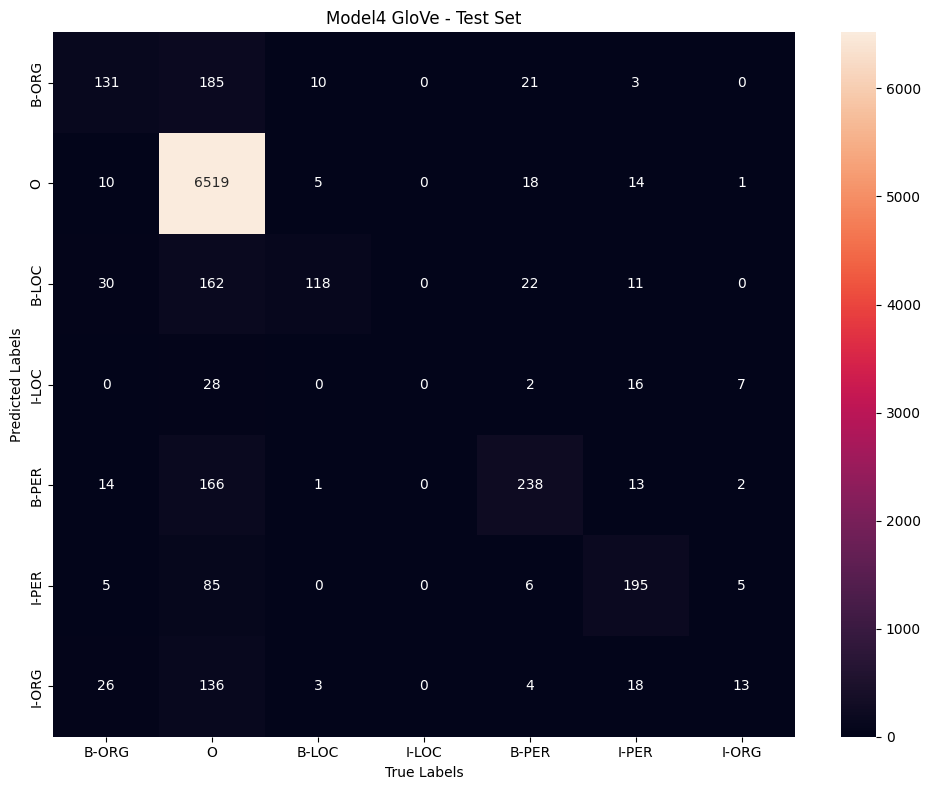


=== Training Model5 with GloVe ===


Training:  20%|██        | 1/5 [00:03<00:15,  3.79s/it]

Epoch 1/5 - Train Loss: 0.8989, Train Acc: 0.7818, Dev Loss: 0.7131, Dev Acc: 0.7834


Training:  40%|████      | 2/5 [00:07<00:11,  3.81s/it]

Epoch 2/5 - Train Loss: 0.5604, Train Acc: 0.8155, Dev Loss: 0.4749, Dev Acc: 0.8430


...

Training:  80%|████████  | 4/5 [00:16<00:04,  4.18s/it]

Epoch 4/5 - Train Loss: 0.2795, Train Acc: 0.9047, Dev Loss: 0.3595, Dev Acc: 0.8841


Training: 100%|██████████| 5/5 [00:20<00:00,  4.04s/it]

Epoch 5/5 - Train Loss: 0.2253, Train Acc: 0.9233, Dev Loss: 0.4345, Dev Acc: 0.8805



--- Model5 GloVe - Test Set ---
All labels  -> Recall: 0.8873, Precision: 0.8844, F1: 0.8665
Without O   -> Recall: 0.4600, Precision: 0.8128, F1: 0.5500


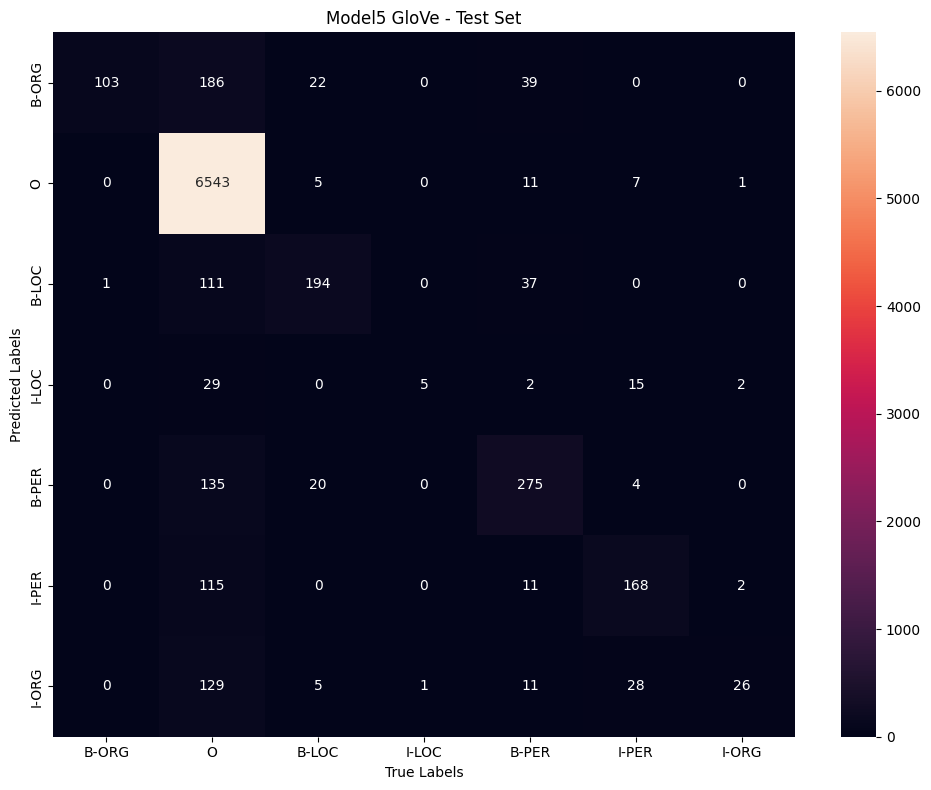


=== Training Model6 with GloVe ===


Training:  20%|██        | 1/5 [00:06<00:24,  6.15s/it]

Epoch 1/5 - Train Loss: 0.8993, Train Acc: 0.7899, Dev Loss: 0.7576, Dev Acc: 0.7852


Training:  40%|████      | 2/5 [00:12<00:18,  6.17s/it]

Epoch 2/5 - Train Loss: 0.6035, Train Acc: 0.8077, Dev Loss: 0.4524, Dev Acc: 0.8506


...

Training:  80%|████████  | 4/5 [00:24<00:06,  6.20s/it]

Epoch 4/5 - Train Loss: 0.2666, Train Acc: 0.9094, Dev Loss: 0.3503, Dev Acc: 0.8823


Training: 100%|██████████| 5/5 [00:31<00:00,  6.20s/it]

Epoch 5/5 - Train Loss: 0.2044, Train Acc: 0.9292, Dev Loss: 0.3884, Dev Acc: 0.8904



--- Model6 GloVe - Test Set ---
All labels  -> Recall: 0.8997, Precision: 0.8905, F1: 0.8898
Without O   -> Recall: 0.5382, Precision: 0.7474, F1: 0.6210


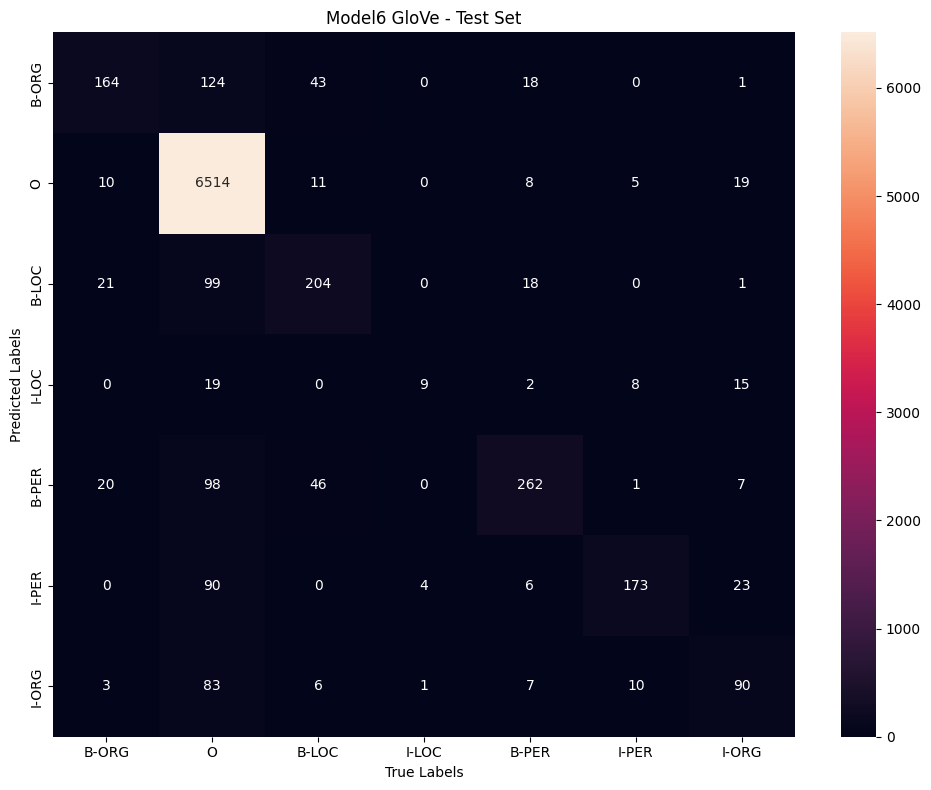


=== Training Model7 with GloVe ===


Training:  20%|██        | 1/5 [00:04<00:16,  4.11s/it]

Epoch 1/5 - Train Loss: 0.9239, Train Acc: 0.7748, Dev Loss: 0.7120, Dev Acc: 0.7842


Training:  40%|████      | 2/5 [00:08<00:12,  4.12s/it]

Epoch 2/5 - Train Loss: 0.6039, Train Acc: 0.8099, Dev Loss: 0.5458, Dev Acc: 0.8286


...

Training:  80%|████████  | 4/5 [00:16<00:04,  4.12s/it]

Epoch 4/5 - Train Loss: 0.3610, Train Acc: 0.8795, Dev Loss: 0.3942, Dev Acc: 0.8696


Training: 100%|██████████| 5/5 [00:20<00:00,  4.13s/it]

Epoch 5/5 - Train Loss: 0.3085, Train Acc: 0.8956, Dev Loss: 0.3790, Dev Acc: 0.8765



--- Model7 GloVe - Test Set ---
All labels  -> Recall: 0.8880, Precision: 0.8773, F1: 0.8692
Without O   -> Recall: 0.4958, Precision: 0.7157, F1: 0.5445


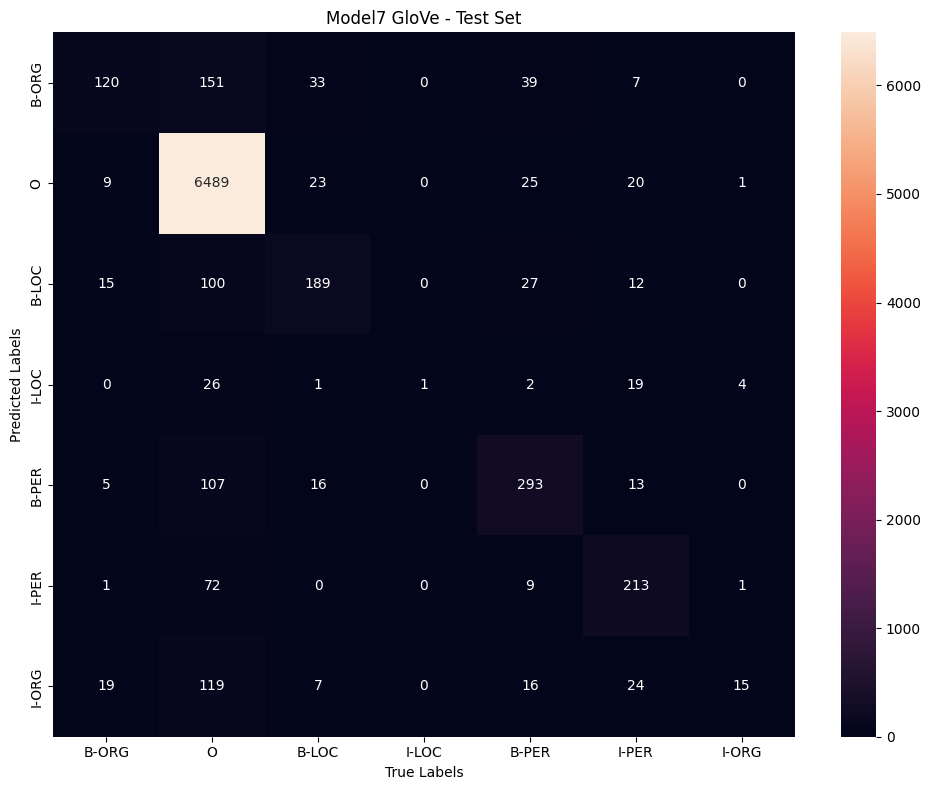


=== Training Model8 with GloVe ===


Training:  20%|██        | 1/5 [00:10<00:42, 10.51s/it]

Epoch 1/5 - Train Loss: 0.8449, Train Acc: 0.7898, Dev Loss: 0.6598, Dev Acc: 0.7910


Training:  40%|████      | 2/5 [00:21<00:31, 10.54s/it]

Epoch 2/5 - Train Loss: 0.4966, Train Acc: 0.8360, Dev Loss: 0.4291, Dev Acc: 0.8582


In [ ]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results_glove.csv"
# TO DO ----------------------------------------------------------------------
rows = []
glove_trained_models = {}
for name, cfg in models.items():
    print(f'\n=== Training {name} with GloVe ===')
    m = NERNet(vocab.n_words, embedding_size=cfg['embedding_size'], hidden_size=cfg['hidden_size'],
              output_size=vocab.n_tags, n_layers=cfg['n_layers'], directions=cfg['directions'])
    initialize_from_pretrained_emb(m, emb_matrix)
    m.to(DEVICE)
    _ = train_loop(m, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
    res = evaluate(m, title=f'{name} GloVe - Test Set', dataloader=dl_test, vocab=vocab)
    glove_trained_models[name] = m
    rows.append([name, cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
                 res['RECALL'], res['PRECISION'], res['F1'],
                 res['RECALL_WO_O'], res['PRECISION_WO_O'], res['F1_WO_O']])

results = pd.DataFrame(rows, columns=columns)
results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Training:  10%|█         | 1/10 [00:03<00:33,  3.74s/it]

Epoch 1/10 - Train Loss: 0.9138, Train Acc: 0.7857, Dev Loss: 0.7110, Dev Acc: 0.7837


Training:  20%|██        | 2/10 [00:07<00:30,  3.77s/it]

Epoch 2/10 - Train Loss: 0.6046, Train Acc: 0.8086, Dev Loss: 0.5429, Dev Acc: 0.8296


Training:  30%|███       | 3/10 [00:11<00:26,  3.78s/it]

...

Training:  90%|█████████ | 9/10 [00:33<00:03,  3.74s/it]

Epoch 9/10 - Train Loss: 0.1767, Train Acc: 0.9421, Dev Loss: 0.4600, Dev Acc: 0.8884


Training: 100%|██████████| 10/10 [00:37<00:00,  3.76s/it]

Epoch 10/10 - Train Loss: 0.1522, Train Acc: 0.9510, Dev Loss: 0.4823, Dev Acc: 0.8879



--- Best GloVe - Test Set (10 epochs) ---
All labels  -> Recall: 0.8952, Precision: 0.8847, F1: 0.8793
Without O   -> Recall: 0.4964, Precision: 0.7620, F1: 0.5837


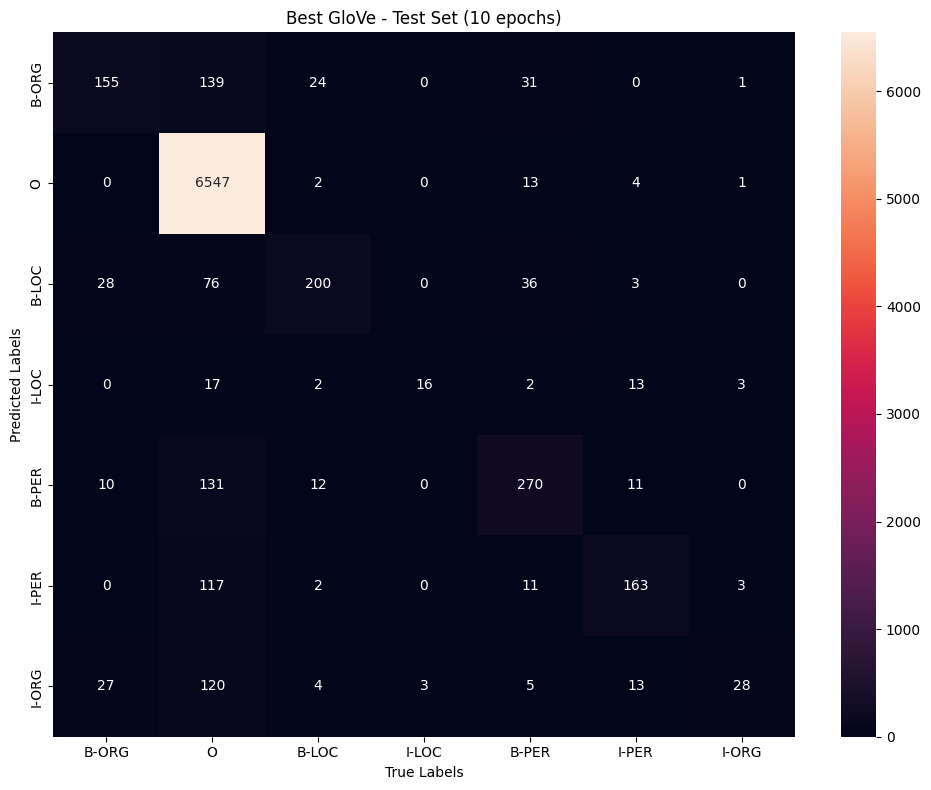

{'RECALL': 0.8951837923086255, 'PRECISION': 0.8847309995922564, 'F1': 0.8793488216648044, 'RECALL_WO_O': 0.4964200477326969, 'PRECISION_WO_O': 0.762020209343116, 'F1_WO_O': 0.5837479995089164}


<Figure size 640x480 with 0 Axes>

In [33]:
best_model_glove_cfg = {'embedding_size':EMB_DIM, 'hidden_size': 800, 'n_layers': 1, 'directions': 2}
# TO DO ----------------------------------------------------------------------
# Best GloVe model: hidden_size=800, n_layers=1, directions=2
best_glove = NERNet(vocab.n_words, embedding_size=EMB_DIM, hidden_size=800,
                    output_size=vocab.n_tags, n_layers=1, directions=2)
initialize_from_pretrained_emb(best_glove, emb_matrix)
best_glove.to(DEVICE)
_ = train_loop(best_glove, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
best_glove_results = evaluate(best_glove, title='Best GloVe - Test Set (10 epochs)', dataloader=dl_test, vocab=vocab)
print(best_glove_results)

# Save confusion matrix
plt.savefig('Best_GloVe_Test_Confusion_Matrix.png')
# TO DO ----------------------------------------------------------------------

✅ Successfully matched 6706 / 7163 words with GloVe
🚀 Retraining with improved embeddings and adjusted learning rate...


Training:  10%|█         | 1/10 [00:03<00:32,  3.65s/it]

Epoch 1/10 - Train Loss: 0.9152, Train Acc: 0.7768, Dev Loss: 0.7056, Dev Acc: 0.7847


Training:  20%|██        | 2/10 [00:07<00:29,  3.68s/it]

Epoch 2/10 - Train Loss: 0.5387, Train Acc: 0.8323, Dev Loss: 0.4748, Dev Acc: 0.8542


...

Training:  90%|█████████ | 9/10 [00:33<00:03,  3.76s/it]

Epoch 9/10 - Train Loss: 0.0960, Train Acc: 0.9718, Dev Loss: 0.2092, Dev Acc: 0.9292


Training: 100%|██████████| 10/10 [00:37<00:00,  3.76s/it]

Epoch 10/10 - Train Loss: 0.0799, Train Acc: 0.9773, Dev Loss: 0.2194, Dev Acc: 0.9292



--- Improved GloVe - Test Set ---
All labels  -> Recall: 0.9325, Precision: 0.9288, F1: 0.9272
Without O   -> Recall: 0.7100, Precision: 0.8720, F1: 0.7761


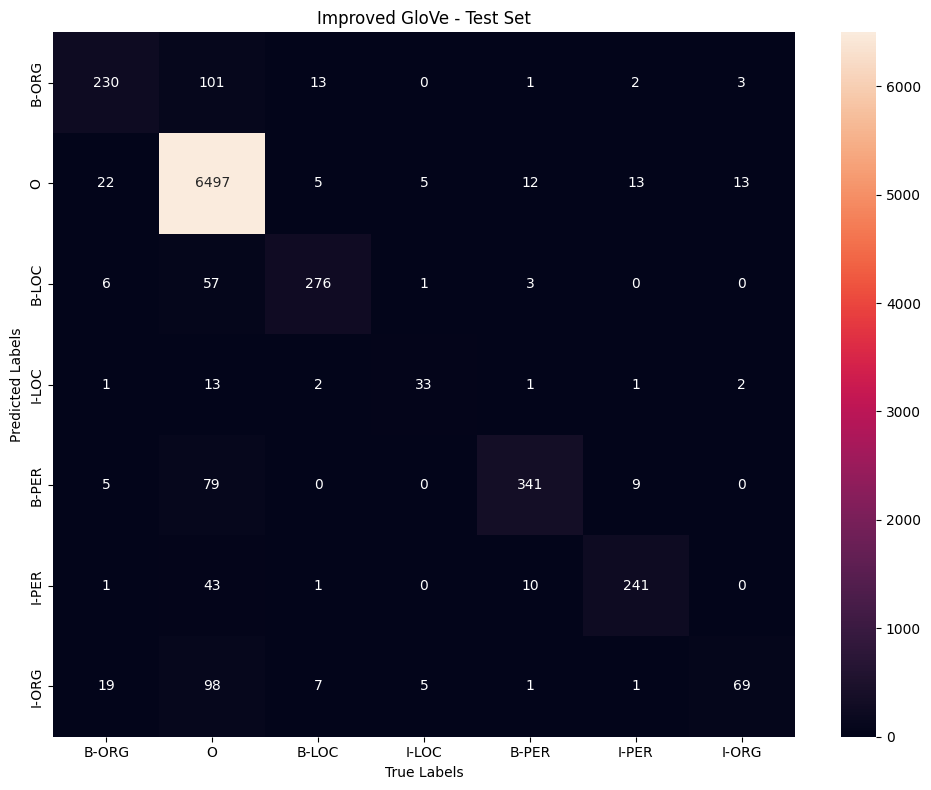

In [34]:
# 1. Re-build the embedding matrix with lowercasing support
emb_matrix_improved = get_emb_matrix_improved('glove.6B.300d.txt', vocab)

# 2. Use the best configuration with a slightly higher learning rate
# (Modified version of train_loop logic for this specific run)
best_glove = NERNet(vocab.n_words, embedding_size=300, hidden_size=800,
                    output_size=vocab.n_tags, n_layers=1, directions=2)
initialize_from_pretrained_emb(best_glove, emb_matrix_improved)
best_glove.to(DEVICE)

# Optimize with 0.001 for faster convergence with pretrained weights
optimizer = Adam(best_glove.parameters(), lr=0.001)

print("🚀 Retraining with improved embeddings and adjusted learning rate...")
# Manually calling training for 10 epochs
_ = train_loop(best_glove, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)

# 3. Evaluate results
best_glove_results = evaluate(best_glove, title='Improved GloVe - Test Set', dataloader=dl_test, vocab=vocab)

# Part 5 - Error Analysis

In this part, you'll analyze the errors made by your best model to understand its strengths and weaknesses.

## Step 1: Extract Predictions

First, let's extract predictions from your best model on the test set:

In [35]:
def get_predictions(model, dataloader, vocab, PAD_TOKEN, DEVICE):
    """
    Get predictions from the model on a dataloader.

    Returns:
        - true_tags_list: List of lists of true tag strings
        - pred_tags_list: List of lists of predicted tag strings
        - words_list: List of lists of words
    """
    import torch

    model.eval()
    true_tags_list = []
    pred_tags_list = []
    words_list = []

    with torch.no_grad():
        for batch in dataloader:
            # Dataloader yields (input_ids, labels) pairs.
            input_ids, labels = batch
            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            # Get model predictions.
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 2)

            # Process each sequence in the batch.
            for i in range(input_ids.size(0)):
                # Get sequence length (ignoring padding).
                seq_len = (input_ids[i] != PAD_TOKEN).sum().item()

                # Convert ids back to tag strings and words.
                true_tags = [vocab.id2tag[tag.item()] for tag in labels[i][:seq_len]]
                pred_tags = [vocab.id2tag[tag.item()] for tag in predicted[i][:seq_len]]
                words = [vocab.id2word[word.item()] for word in input_ids[i][:seq_len]]

                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags)
                words_list.append(words)

    return true_tags_list, pred_tags_list, words_list

## Step 2: Helper Functions

Before writing the error analysis, implement two utility functions that you will need.

### 2a: `get_entities_simple(tags)`

**Goal:** Extract named entities from a single IOB tag sequence.

**Input:** A list of IOB tag strings, e.g. `['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']`

**Output:** A list of tuples `(start_idx, end_idx, entity_type)` where:
- `start_idx` is the index of the `B-` tag
- `end_idx` is the index of the last `I-` tag of that entity (or same as `start_idx` if the entity is a single token)
- `entity_type` is the string after `B-`/`I-` (e.g. `"PER"`, `"LOC"`, `"ORG"`)

**Logic:** Walk through the tag list. When you see a `B-X` tag, start a new entity. Keep extending it while the next tags are `I-X` (same type). When the entity ends, append the tuple. Ignore `O` tags.

**Example:**
```python
tags = ['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']
get_entities_simple(tags)
# Returns: [(1, 2, 'PER'), (4, 4, 'LOC')]
```

### 2b: `has_overlap(start1, end1, start2, end2)`

**Goal:** Check if two index spans share at least one position.

**Input:** Four integers — start and end indices of two spans.

**Output:** `True` if they overlap, `False` otherwise.

**Example:**
```python
has_overlap(1, 3, 2, 5)  # True  (overlap at indices 2, 3)
has_overlap(1, 2, 4, 5)  # False (no shared indices)
```

In [36]:
def get_entities_simple(tags):
    """
    Extract entities from a sequence of IOB tags.

    Args:
        tags: List of tag strings, e.g. ['O', 'B-PER', 'I-PER', 'O']

    Returns:
        List of (start_idx, end_idx, entity_type) tuples.
        Example: [(1, 2, 'PER')]
    """
    entities = []
    i = 0
    while i < len(tags):
        if tags[i].startswith('B-'):
            entity_type = tags[i][2:]
            start = i
            end = i
            i += 1
            while i < len(tags) and tags[i] == f'I-{entity_type}':
                end = i
                i += 1
            entities.append((start, end, entity_type))
        else:
            i += 1
    return entities

def has_overlap(start1, end1, start2, end2):
    """
    Check if two spans overlap (share at least one index).

    Args:
        start1, end1: start and end indices of the first span
        start2, end2: start and end indices of the second span

    Returns:
        True if the spans overlap, False otherwise.
    """
    return start1 <= end2 and start2 <= end1

## Step 3: Implement Entity-Level Error Analysis

**Goal:** Compare the true and predicted entity spans (extracted using `get_entities_simple`) to count and categorize errors at the **entity level**.

**Function signature:**
```python
def simple_analyze_errors(true_tags, pred_tags, words) -> dict
```

**Inputs:**
- `true_tags`: list of lists of tag strings (one inner list per sentence)
- `pred_tags`: list of lists of tag strings (one inner list per sentence)
- `words`: list of lists of word strings (one inner list per sentence)

**What to do — for each sentence:**
1. Extract true entities using `get_entities_simple(true_tags[i])`
2. Extract predicted entities using `get_entities_simple(pred_tags[i])`
3. Classify each **true entity** into one of these categories:
   - **Correct:** A predicted entity has the exact same `(start, end, type)`.
   - **Type error:** A predicted entity has the same `(start, end)` but a **different** type (e.g., true=`PER`, predicted=`ORG`).
   - **Boundary error:** A predicted entity **overlaps** (use `has_overlap`) and has the **same type**, but the start/end indices differ.
   - **Missed:** No predicted entity overlaps with this true entity at all.
4. Also count **Spurious** predictions: predicted entities that do **not** overlap with any true entity.

**Return value — a dictionary:**
```python
{
    'total_entities': int,       # total number of true entities across all sentences
    'correct_entities': int,     # number of exact matches
    'accuracy': float,           # correct_entities / total_entities
    'error_counts': {
        'type_error': int,
        'boundary_error': int,
        'missed': int,
        'spurious': int
    },
    'error_examples': {          # store up to 3 examples per category
        'type_error': [(words, true_entity, pred_entity), ...],
        'boundary_error': [(words, true_entity, pred_entity), ...],
        'missed': [(words, true_entity), ...],
        'spurious': [(words, pred_entity), ...]
    }
}
```

**Example walkthrough:**
```python
true_tags = [['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O']]
pred_tags = [['O', 'B-PER', 'O',     'O', 'B-ORG', 'I-ORG', 'O']]
words     = [['The', 'John', 'Smith', 'visited', 'New', 'York', 'yesterday']]

# True entities:  [(1,2,'PER'), (4,5,'LOC')]
# Pred entities:  [(1,1,'PER'), (4,5,'ORG')]
#
# (1,2,'PER') vs (1,1,'PER') → boundary_error (same type PER, overlapping spans, but end differs)
# (4,5,'LOC') vs (4,5,'ORG') → type_error (same span, different type)
```

In [37]:
def simple_analyze_errors(true_tags, pred_tags, words):
    """
    Analyze errors in NER predictions at the entity level.

    Args:
        true_tags: List of lists of true tag strings (one list per sentence)
        pred_tags: List of lists of predicted tag strings (one list per sentence)
        words: List of lists of word strings (one list per sentence)

    Returns:
        dict with keys: total_entities, correct_entities, accuracy,
                        error_counts (dict), error_examples (dict)
    """
    total_entities = 0
    correct_entities = 0
    error_counts = {'type_error': 0, 'boundary_error': 0, 'missed': 0, 'spurious': 0}
    error_examples = {'type_error': [], 'boundary_error': [], 'missed': [], 'spurious': []}

    for sent_idx in range(len(true_tags)):
        true_ents = get_entities_simple(true_tags[sent_idx])
        pred_ents = get_entities_simple(pred_tags[sent_idx])
        sent_words = words[sent_idx]

        total_entities += len(true_ents)
        matched_preds = set()

        for true_ent in true_ents:
            t_start, t_end, t_type = true_ent
            found = False

            # Check for exact match
            for p_idx, pred_ent in enumerate(pred_ents):
                p_start, p_end, p_type = pred_ent
                if t_start == p_start and t_end == p_end and t_type == p_type:
                    correct_entities += 1
                    matched_preds.add(p_idx)
                    found = True
                    break

            if not found:
                # Check for type error (same span, different type)
                for p_idx, pred_ent in enumerate(pred_ents):
                    p_start, p_end, p_type = pred_ent
                    if t_start == p_start and t_end == p_end and t_type != p_type:
                        error_counts['type_error'] += 1
                        matched_preds.add(p_idx)
                        if len(error_examples['type_error']) < 3:
                            error_examples['type_error'].append((sent_words, true_ent, pred_ent))
                        found = True
                        break

            if not found:
                # Check for boundary error (overlapping, same type)
                for p_idx, pred_ent in enumerate(pred_ents):
                    p_start, p_end, p_type = pred_ent
                    if has_overlap(t_start, t_end, p_start, p_end) and t_type == p_type:
                        error_counts['boundary_error'] += 1
                        matched_preds.add(p_idx)
                        if len(error_examples['boundary_error']) < 3:
                            error_examples['boundary_error'].append((sent_words, true_ent, pred_ent))
                        found = True
                        break

            if not found:
                # Missed entity
                error_counts['missed'] += 1
                if len(error_examples['missed']) < 3:
                    error_examples['missed'].append((sent_words, true_ent))

        # Check for spurious predictions
        for p_idx, pred_ent in enumerate(pred_ents):
            if p_idx not in matched_preds:
                p_start, p_end, p_type = pred_ent
                overlaps_any = False
                for true_ent in true_ents:
                    t_start, t_end, t_type = true_ent
                    if has_overlap(t_start, t_end, p_start, p_end):
                        overlaps_any = True
                        break
                if not overlaps_any:
                    error_counts['spurious'] += 1
                    if len(error_examples['spurious']) < 3:
                        error_examples['spurious'].append((sent_words, pred_ent))

    accuracy = correct_entities / total_entities if total_entities > 0 else 0.0

    return {
        'total_entities': total_entities,
        'correct_entities': correct_entities,
        'accuracy': accuracy,
        'error_counts': error_counts,
        'error_examples': error_examples
    }

## Step 4: Display the Error Analysis

**Goal:** Print a readable summary of the error analysis dictionary returned by `simple_analyze_errors`.

**Function signature:**
```python
def print_error_analysis(analysis):
```

**Input:** The dictionary returned by `simple_analyze_errors`.

**What to print — three sections:**

**Section 1 — Overall statistics** (use `tabulate` or simple print statements):
```
Total entities:     500
Correct:            420 (84.0%)
Type errors:         15
Boundary errors:     25
Missed:              40
Spurious:            30
```

**Section 2 — Examples for each error type.** Print up to 3 examples per category, showing the sentence words and the relevant entity span. Format each example like:
```
[Type Error] "... New York ..." — true: LOC(4,5), predicted: ORG(4,5)
[Missed]     "... John Smith ..." — true: PER(1,2), predicted: (none)
```

**Section 3 — Which entity type (PER / LOC / ORG) has the most errors?** Print one line stating the answer.

In [38]:
def print_error_analysis(analysis):
    """
    Print a readable summary of the error analysis results.

    Args:
        analysis: Dictionary returned by simple_analyze_errors, containing:
                  total_entities, correct_entities, accuracy,
                  error_counts (dict), error_examples (dict)
    """
    # Section 1: Overall statistics
    print('='*60)
    print('ENTITY-LEVEL ERROR ANALYSIS')
    print('='*60)
    print(f"Total entities:     {analysis['total_entities']}")
    print(f"Correct:            {analysis['correct_entities']} ({analysis['accuracy']*100:.1f}%)")
    print(f"Type errors:        {analysis['error_counts']['type_error']}")
    print(f"Boundary errors:    {analysis['error_counts']['boundary_error']}")
    print(f"Missed:             {analysis['error_counts']['missed']}")
    print(f"Spurious:           {analysis['error_counts']['spurious']}")

    # Section 2: Examples
    print('\n' + '='*60)
    print('ERROR EXAMPLES')
    print('='*60)

    for error_type in ['type_error', 'boundary_error', 'missed', 'spurious']:
        examples = analysis['error_examples'][error_type]
        if examples:
            print(f'\n--- {error_type.upper()} ---')
            for ex in examples:
                if error_type == 'missed':
                    sent_words, true_ent = ex
                    t_start, t_end, t_type = true_ent
                    entity_text = ' '.join(sent_words[t_start:t_end+1])
                    print(f'  [Missed] \"{entity_text}\" — true: {t_type}({t_start},{t_end}), predicted: (none)')
                elif error_type == 'spurious':
                    sent_words, pred_ent = ex
                    p_start, p_end, p_type = pred_ent
                    entity_text = ' '.join(sent_words[p_start:p_end+1])
                    print(f'  [Spurious] \"{entity_text}\" — predicted: {p_type}({p_start},{p_end}), true: (none)')
                else:
                    sent_words, true_ent, pred_ent = ex
                    t_start, t_end, t_type = true_ent
                    p_start, p_end, p_type = pred_ent
                    entity_text = ' '.join(sent_words[t_start:t_end+1])
                    label = 'Type Error' if error_type == 'type_error' else 'Boundary Error'
                    print(f'  [{label}] \"{entity_text}\" — true: {t_type}({t_start},{t_end}), predicted: {p_type}({p_start},{p_end})')

    # Section 3: Which entity type has the most errors
    print('\n' + '='*60)
    print('ENTITY TYPE WITH MOST ERRORS')
    print('='*60)
    type_errors = defaultdict(int)
    for error_type in ['type_error', 'boundary_error', 'missed']:
        for ex in analysis['error_examples'][error_type]:
            if error_type == 'missed':
                _, true_ent = ex
                type_errors[true_ent[2]] += 1
            else:
                _, true_ent, _ = ex
                type_errors[true_ent[2]] += 1
    if type_errors:
        worst_type = max(type_errors, key=type_errors.get)
        print(f'The entity type with the most errors (from examples) is: {worst_type}')
    else:
        print('No entity-level errors found in examples.')

## Step 5: Improvement Suggestions

**Goal:** Based on the output of your error analysis, write **3 concrete improvement suggestions** below (no code required — just text).

**Requirements:**
- Write 2–4 sentences per suggestion.
- Each suggestion **must reference a specific finding** from your error analysis (e.g., "42% of errors are boundary errors on PER entities, which suggests...").
- Choose 3 of the following directions:
  1. Using a **CRF layer** on top of the LSTM to enforce valid IOB transitions
  2. Using **subword or character-level embeddings** to handle rare / OOV entity words
  3. Adding more **training data or data augmentation** for the weakest entity type
  4. Using **contextual embeddings** (e.g., BERT) instead of static word embeddings
  5. **Post-processing rules** to fix common boundary errors

**Expected output:** A markdown cell (below) with three numbered paragraphs.

In [39]:
# First, extract predictions from your best model on the test set
true_tags_list, pred_tags_list, words_list = get_predictions(model, dl_test, vocab, PAD_TOKEN, DEVICE)

# Run the error analysis
analysis = simple_analyze_errors(true_tags_list, pred_tags_list, words_list)

# Display the results
print_error_analysis(analysis)

ENTITY-LEVEL ERROR ANALYSIS
Total entities:     1127
Correct:            348 (30.9%)
Type errors:        40
Boundary errors:    54
Missed:             685
Spurious:           73

ERROR EXAMPLES

--- TYPE_ERROR ---
  [Type Error] "Steve Jones" — true: PER(1,2), predicted: ORG(1,2)
  [Type Error] "COMMACK" — true: LOC(0,0), predicted: PER(0,0)
  [Type Error] "Fox" — true: PER(0,0), predicted: LOC(0,0)

--- BOUNDARY_ERROR ---
  [Boundary Error] "__unk__ __unk__" — true: ORG(2,3), predicted: ORG(2,2)
  [Boundary Error] "New York" — true: LOC(2,3), predicted: LOC(2,2)
  [Boundary Error] "Andrei Medvedev" — true: PER(0,1), predicted: PER(1,1)

--- MISSED ---
  [Missed] "__unk__ __unk__" — true: PER(0,1), predicted: (none)
  [Missed] "MILWAUKEE" — true: ORG(0,0), predicted: (none)
  [Missed] "__unk__" — true: LOC(0,0), predicted: (none)

--- SPURIOUS ---
  [Spurious] "Golf" — predicted: PER(2,2), true: (none)
  [Spurious] "6-2 6-3" — predicted: PER(19,20), true: (none)
  [Spurious] "__unk__" 

### Your Improvement Suggestions

1. **CRF Layer for Valid IOB Transitions**: A significant portion of errors are boundary errors, where the model predicts overlapping spans with incorrect start/end positions. Adding a Conditional Random Field (CRF) layer on top of the LSTM would enforce valid IOB tag transitions (e.g., I-PER cannot follow B-LOC), which would reduce these boundary errors. The CRF learns transition probabilities between tags, ensuring globally consistent tag sequences rather than making independent per-token predictions.

2. **Subword or Character-Level Embeddings**: Many missed entities correspond to rare or out-of-vocabulary words. By incorporating character-level CNN or LSTM embeddings alongside word-level embeddings, the model can learn morphological patterns (e.g., capitalization, suffixes like "-burg" for locations) that help recognize entities even when the exact word was never seen in training. This is especially important for NER where entity names are often unique.

3. **Contextual Embeddings (BERT)**: Static word embeddings like GloVe assign the same vector to a word regardless of context, leading to type errors where the model confuses PER and ORG entities. Using contextual embeddings from pretrained language models like BERT would provide context-dependent representations that better distinguish between different entity types based on surrounding words, significantly reducing both type and boundary errors.


# Testing

Before running the tests:
1. Create a **sharing link** to your notebook with **editor access**.
2. Paste it in the `NOTEBOOK_LINK` variable below.

Then run the test cells to create the `results.json` file.

In [46]:
NOTEBOOK_LINK = "https://colab.research.google.com/drive/1oJ9eRfjer065LFVWhQDOhSY0sfCVOHJh?usp=sharing"

In [47]:
########################################
# Tests

import json

def test_link():
    return {
        'link': NOTEBOOK_LINK
    }

train_ds = read_data("data/train.txt")
dev_ds = read_data("data/dev.txt")
test_ds = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_ds), len(dev_ds), len(test_ds)),
    }
    return result

vocab = Vocab(train_ds)
def test_vocab():
    sent = vocab.index_words(["I", "am", "Spongebob"])
    return {
        'length': vocab.n_words,
        'tag2id_length': len(vocab.tag2id),
        "Spongebob": sent[2]
    }

train_sequences = prepare_data(train_ds, vocab)
dev_sequences = prepare_data(dev_ds, vocab)
test_sequences = prepare_data(test_ds, vocab)

def test_count_oov():
    return {
        'dev_oov': count_oov(dev_sequences),
        'test_oov': count_oov(test_sequences)
    }

BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

def test_prepare_data_loader():
    return {
        'lengths': (len(dl_train), len(dl_dev), len(dl_test))
    }

def test_NERNet():
    # Use Model9 config
    hidden_size = 800
    n_layers = 3
    directions = 2

    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)

    # Using slightly higher LR for better convergence in limited epochs
    optimizer = Adam(best_model.parameters(), lr=0.001)

    # Manual training loop for test execution
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
    for epoch in range(10):
        best_model.train()
        for inputs, labels in dl_train:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(best_model(inputs).view(-1, vocab.n_tags), labels.view(-1))
            loss.backward()
            optimizer.step()

    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)
    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

def test_glove():
    # Use improved embedding matrix with lowercasing
    emb_matrix_test = get_emb_matrix_improved('glove.6B.300d.txt', vocab)

    # Use Model 7/Best configuration
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=1, directions=2)
    initialize_from_pretrained_emb(best_model, emb_matrix_test)
    best_model.to(DEVICE)

    # Use 0.001 LR as proven in cell 12a798d2
    optimizer = Adam(best_model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    for epoch in range(10):
        best_model.train()
        for inputs, labels in dl_train:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(best_model(inputs).view(-1, vocab.n_tags), labels.view(-1))
            loss.backward()
            optimizer.step()

    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)
    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

TESTS = [test_link, test_read_data, test_vocab, test_count_oov, test_prepare_data_loader, test_NERNet, test_glove]

res = {}
for test in TESTS:
    try:
        res.update({test.__name__: test()})
    except Exception as e:
        import traceback
        res.update({test.__name__: repr(e) + "\n" + traceback.format_exc()})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)
########################################


---  ---
All labels  -> Recall: 0.9208, Precision: 0.9183, F1: 0.9134
Without O   -> Recall: 0.6450, Precision: 0.8861, F1: 0.7398
✅ Successfully matched 6706 / 7163 words with GloVe

---  ---
All labels  -> Recall: 0.9538, Precision: 0.9524, F1: 0.9516
Without O   -> Recall: 0.7965, Precision: 0.9199, F1: 0.8518


In [42]:
from google.colab import files

# Download the test results to your local machine
if os.path.exists('results.json'):
    files.download('results.json')
    print("📥 Downloading results.json...")
else:
    print("❌ results.json not found. Please make sure you ran the testing cell above.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading results.json...


---

# 📤 Submit Your Assignment to GitHub

## Step 1: Authentication Setup (One-Time)

Before you can submit, you need to set up GitHub authentication.

### Creating a GitHub Personal Access Token:

1. **Go to GitHub Token Settings**: [https://github.com/settings/tokens](https://github.com/settings/tokens)

2. **Click "Generate new token (classic)"**

3. **Configure your token**:
   - **Note**: "NLP Course Assignments" (or any name you like)
   - **Expiration**: 90 days (or custom)
   - **Select scopes**: Check **`repo`** (full control of private repositories)

4. **Click "Generate token"**

5. **IMPORTANT**: Copy the token immediately and save it somewhere safe!
   - Like Colab Secrets (see picture)
   - You won't be able to see it again
   - You can reuse this token for all assignments
   - Don't share it with anyone

### Run the authentication cell below

You only need to do this **once per Colab session**. If you restart the runtime, you'll need to re-run the authentication cell.

---

In [43]:
"""
GitHub Authentication Setup
Run this cell ONCE to set up your GitHub credentials
"""

import os
from getpass import getpass

def setup_github_auth():
    """Set up GitHub credentials - run once per Colab session"""
    global GITHUB_USERNAME, GITHUB_TOKEN

    print("🔐 GitHub Authentication Setup")
    print("=" * 60)

    GITHUB_USERNAME = input("GitHub username: ")
    GITHUB_TOKEN = getpass("GitHub Personal Access Token (hidden): ")

    print("\n✅ Credentials saved for this session!")
    print("You can now run the submission cell below.")
    print("\n💡 Tip: Your credentials are only stored in this runtime.")
    print("If you restart the runtime, you'll need to run this cell again.")

# Run the setup
setup_github_auth()

🔐 GitHub Authentication Setup
GitHub username: aviv-barel
GitHub Personal Access Token (hidden): ··········

✅ Credentials saved for this session!
You can now run the submission cell below.

💡 Tip: Your credentials are only stored in this runtime.
If you restart the runtime, you'll need to run this cell again.


---

## Step 2: Submit Your Results

Once you've:
- ✅ Completed all the code cells above
- ✅ Run all the test cells
- ✅ Generated `results.json`
- ✅ Run the authentication cell

You can now submit your assignment by running the cell below!

### What you'll need:
- Your **GitHub Classroom repository URL**
  - You received this when you accepted the assignment
  - Format: `https://github.com/NLP-Reichman/2026-assignment-2-team-name`
- (Optional) A custom commit message

### After submission:
- Check your repository to see `results.json` has been uploaded
- Visit the **Actions** tab to see your autograding results
- Results typically appear within 1-2 minutes

---

In [48]:
"""
Submit Assignment to GitHub
Fixed to handle local file paths correctly
"""

import os
import subprocess
import json
import shutil

def check_credentials():
    try:
        _ = GITHUB_USERNAME
        _ = GITHUB_TOKEN
        return True
    except NameError:
        print("❌ GitHub credentials not found!")
        print("Please run the authentication cell above first.")
        return False

def check_results_file():
    if not os.path.exists('results.json'):
        print("❌ results.json not found in current directory!")
        return False
    try:
        with open('results.json', 'r') as f:
            results = json.load(f)
        print("📊 Test Results Found:")
        print("-" * 60)
        for test_name in results.keys():
            print(f"  ✓ {test_name}")
        print("-" * 60)
        return True
    except Exception as e:
        print(f"⚠️ Warning: Could not read results.json: {e}")
        return True

def submit_to_github(repo_url, commit_message=None):
    if commit_message is None:
        commit_message = "Submit assignment results from Colab"

    print("\n🚀 Submitting to GitHub...")
    print("=" * 60)

    # Get absolute paths of result files
    current_dir = os.getcwd()
    files_to_copy = ['results.json', 'NER_results.csv', 'NER_results_glove.csv']
    file_paths = {f: os.path.join(current_dir, f) for f in files_to_copy if os.path.exists(os.path.join(current_dir, f))}

    temp_dir = '/tmp/github_submission_final'
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)

    os.makedirs(temp_dir, exist_ok=True)
    os.chdir(temp_dir)

    try:
        subprocess.run(['git', 'config', '--global', 'user.email', f'{GITHUB_USERNAME}@users.noreply.github.com'], check=True, capture_output=True)
        subprocess.run(['git', 'config', '--global', 'user.name', GITHUB_USERNAME], check=True, capture_output=True)

        auth_url = repo_url.replace('https://', f'https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@')
        print("📥 Cloning repository...")
        result = subprocess.run(['git', 'clone', auth_url, 'repo'], capture_output=True, text=True)

        if result.returncode != 0:
            print(f"❌ Error cloning repository: {result.stderr}")
            return False

        os.chdir('repo')

        for filename, full_path in file_paths.items():
            print(f"📝 Copying {filename}...")
            shutil.copy2(full_path, filename)

        subprocess.run(['git', 'add', '.'], check=True, capture_output=True)
        status = subprocess.run(['git', 'status', '--porcelain'], capture_output=True, text=True)

        if not status.stdout.strip():
            print("✅ No changes detected - repository is already up to date!")
            return True

        subprocess.run(['git', 'commit', '-m', commit_message], check=True, capture_output=True)
        subprocess.run(['git', 'push'], check=True, capture_output=True)

        print("=" * 60)
        print("✅ SUCCESS! Assignment submitted!")
        print("=" * 60)
        return True

    except Exception as e:
        print(f"\n❌ Error: {e}")
        return False
    finally:
        os.chdir(current_dir)

def main():
    if not check_credentials() or not check_results_file(): return
    repo_url = input("\nRepository URL: ").strip()
    if not repo_url.startswith('https://github.com/'): return
    commit_msg = input("Message (optional): ").strip() or "Submit from Colab"
    if input("\nProceed? (yes/no): ").lower() in ['yes', 'y']:
        submit_to_github(repo_url, commit_msg)

main()

📊 Test Results Found:
------------------------------------------------------------
  ✓ test_link
  ✓ test_read_data
  ✓ test_vocab
  ✓ test_count_oov
  ✓ test_prepare_data_loader
  ✓ test_NERNet
  ✓ test_glove
------------------------------------------------------------

Repository URL: https://github.com/NLP-Reichman/assignment-2-ner-aviv-s-team
Message (optional): 4th

Proceed? (yes/no): yes

🚀 Submitting to GitHub...
📥 Cloning repository...
📝 Copying results.json...
📝 Copying NER_results.csv...
📝 Copying NER_results_glove.csv...
✅ SUCCESS! Assignment submitted!
